In [1]:
## import libraries

import pandas as pd

# graphics

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Preparations for formatting the percentage axis of charts
from matplotlib.ticker import PercentFormatter
ticks = PercentFormatter(xmax=100, decimals=0, symbol='%')

In [2]:
# Number formatting

format= {'f' : '{:.0f}', '%' : '{:.2f}%'}

In [3]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/MyDrive/data

Mounted at /gdrive
/gdrive/MyDrive/data


In [4]:
# Select the dataframe

df = pd.read_csv('IBH_HR_ATTRITION_DATASET.csv')

In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "Over18"])

In [9]:
# Ensure demography_subset is a modifiable copy and convert 'Attrition' to numerical
# demography_subset = df[['Age', 'Gender', 'MaritalStatus', 'Education', 'EducationField', 'Attrition']].copy()
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1}).astype(int)

df['Attrition'].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


Checked on SciKit documentation and it's not needed

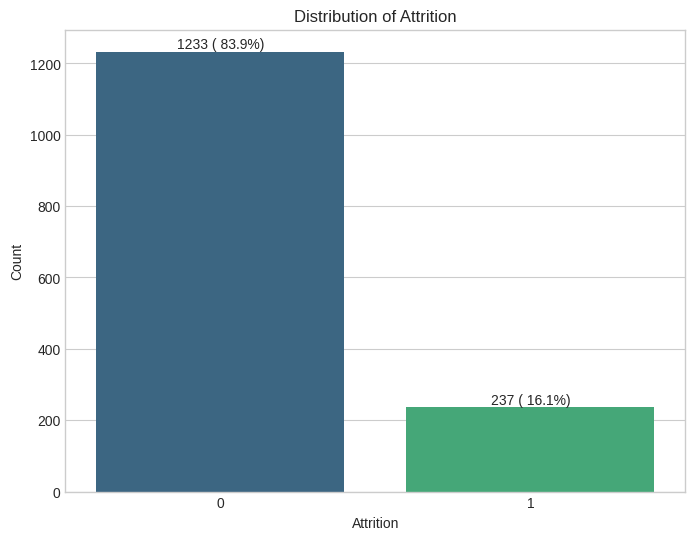

In [10]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(df, x='Attrition', hue='Attrition', legend=False, palette='viridis')
plt.title('Distribution of Attrition')
plt.xlabel('Attrition')
plt.ylabel('Count')

total = len(df['Attrition'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{int(y)} ( {percentage})', (x, y), ha='center', va='bottom')

plt.show()

**Overall Attrition**: Out of 1470 employees, 237 (approximately 16.1%) have attrited, while 1233 (approximately 83.9%) have not. This indicates that attrition is a notable issue, though the majority of employees remain.

**Definition of Attrition**
In the context of human resources, Attrition refers to the reduction in staff numbers that occurs when employees leave a company (due to reasons like resignation, retirement, or transfer) and are not replaced. It's often used interchangeably with turnover and can be a critical metric for understanding workforce stability and employee satisfaction.

**Problem Formulation**
The primary problem we are addressing is:

To identify the key factors influencing employee attrition and develop predictive models that can accurately forecast which employees are at a higher risk of leaving the company. By understanding these drivers and predicting attrition, the company can proactively implement targeted retention strategies, improve employee satisfaction, optimize workforce planning, and ultimately reduce the costs associated with high employee turnover.

## Demography Analysis

In [11]:
# Create Y DataFrame with 'Attrition' column
# Y = df[['Attrition']]

# Create demography DataFrame with specified features
demography_subset = df[['Age', 'Gender', 'MaritalStatus', 'Education', 'EducationField', 'Attrition']]

In [12]:
demography_subset.head()

,Age,Gender,MaritalStatus,Education,EducationField,Attrition
0,41,Female,Single,2,Life Sciences,1
1,49,Male,Married,1,Life Sciences,0
2,37,Male,Single,2,Other,1
3,33,Female,Married,4,Life Sciences,0
4,27,Male,Married,1,Medical,0


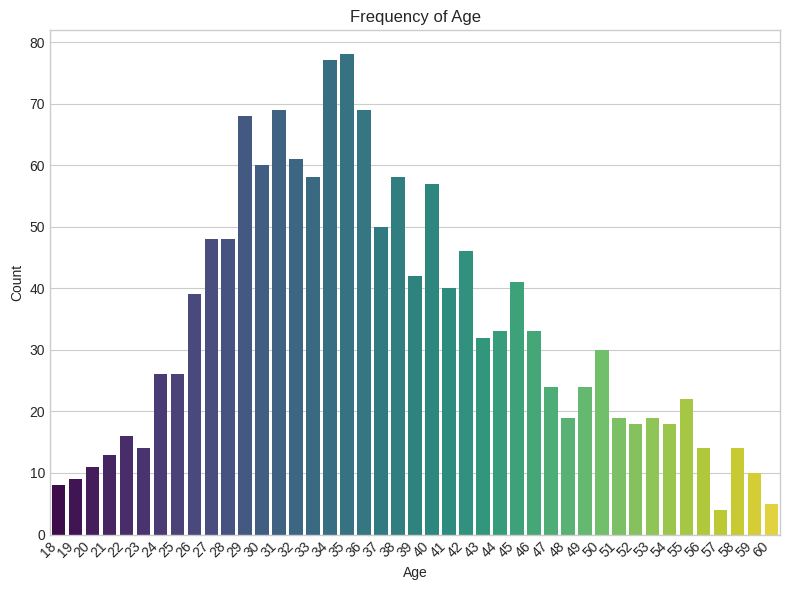

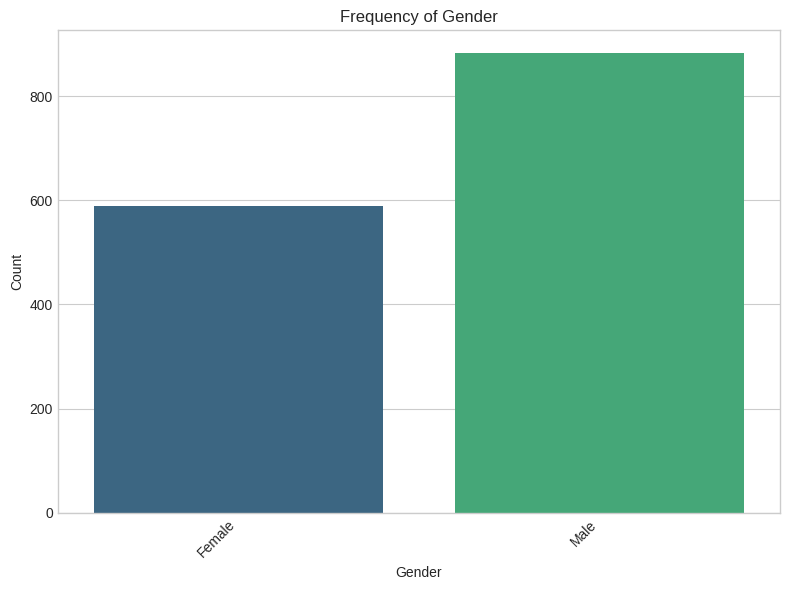

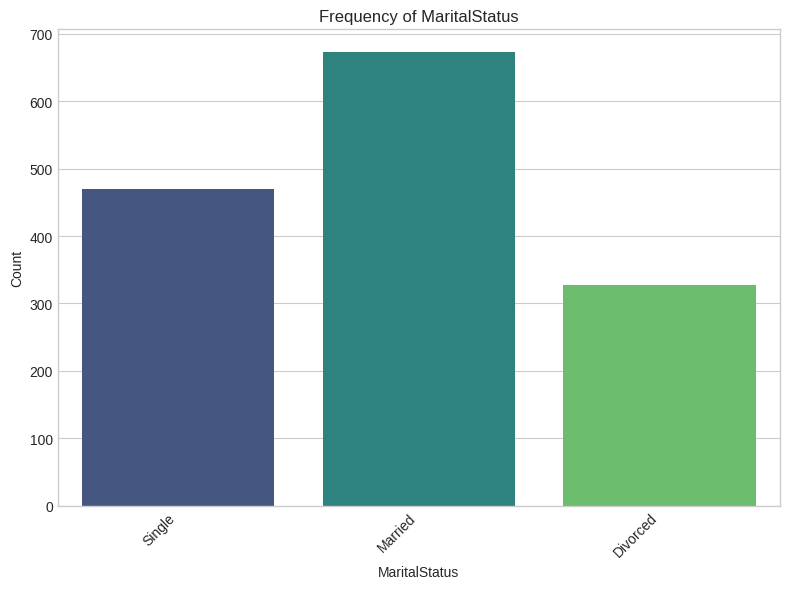

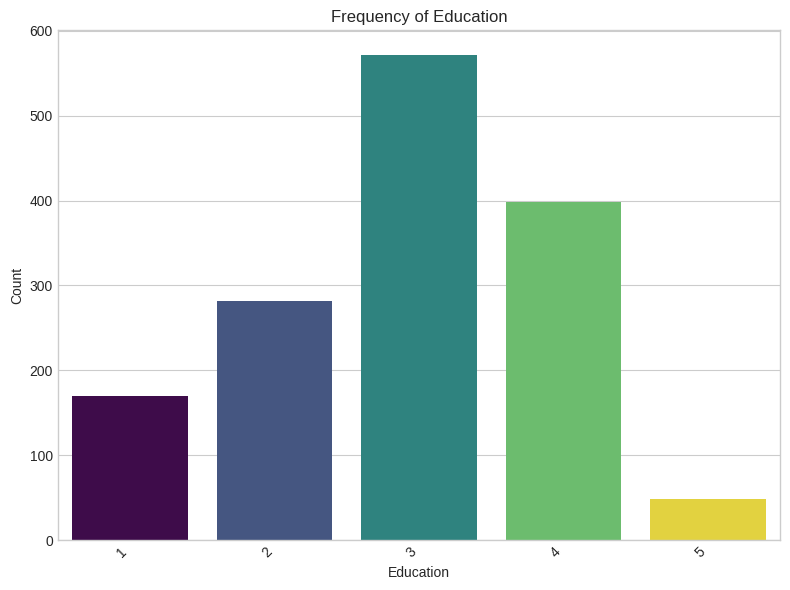

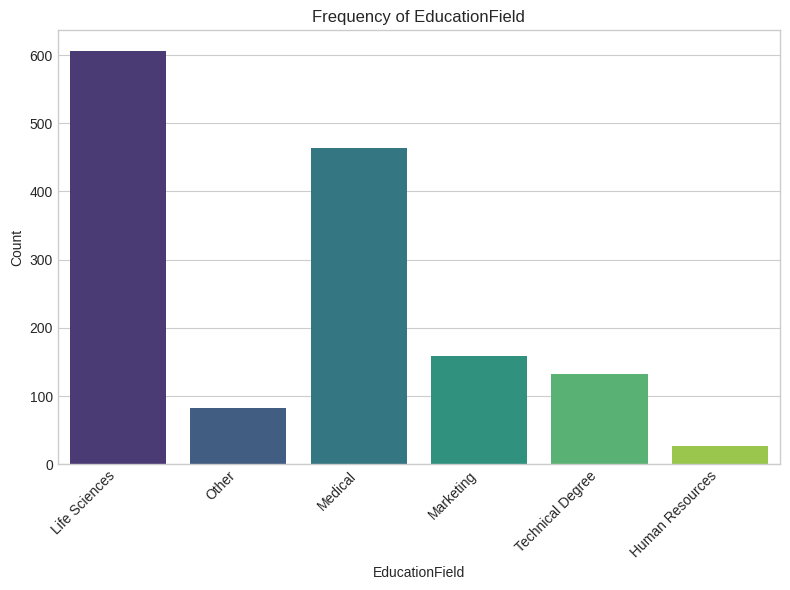

In [13]:
for column in ['Age', 'Gender', 'MaritalStatus', 'Education', 'EducationField']:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=demography_subset, x=column, hue=column, legend=False, palette='viridis')
    plt.title(f'Frequency of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [14]:
Y = df[['Attrition']].copy()
demography_subset = df[['Age', 'Gender', 'MaritalStatus', 'Education', 'EducationField', 'Attrition']].copy()

To further analyze the demographic data, I will now create custom age groups within the `demography_subset` DataFrame. This will allow for a more structured analysis of attrition rates across different age brackets.



In [15]:
bins = [18, 25, 35, 45, 55, 60]
labels = ['18-24', '25-34', '35-44', '45-54', '55-60']
demography_subset['AgeGroup'] = pd.cut(demography_subset['Age'], bins=bins, labels=labels, right=False)

print("Value counts for 'AgeGroup':\n")
print(demography_subset['AgeGroup'].value_counts().sort_index())

Value counts for 'AgeGroup':

AgeGroup
18-24     97
25-34    554
35-44    505
45-54    245
55-60     64
Name: count, dtype: int64


Now that the 'AgeGroup' column is correctly established in the `demography_subset` DataFrame, I will group the data by 'Gender', 'MaritalStatus', 'Education', 'EducationField', and 'AgeGroup', and then calculate the mean attrition rate for each of these demographic groups. This will allow for an initial assessment of how attrition varies across these categories.



In [16]:
# useful for next visualizations
grouped_attrition = demography_subset.groupby(['Gender', 'MaritalStatus', 'Education', 'EducationField', 'AgeGroup'], observed=False)['Attrition'].mean().reset_index()
print("Mean attrition rate by demographic groups:")
print(grouped_attrition.head())

Mean attrition rate by demographic groups:
   Gender MaritalStatus  Education   EducationField AgeGroup  Attrition
0  Female      Divorced          1  Human Resources    18-24        NaN
1  Female      Divorced          1  Human Resources    25-34        NaN
2  Female      Divorced          1  Human Resources    35-44        NaN
3  Female      Divorced          1  Human Resources    45-54        NaN
4  Female      Divorced          1  Human Resources    55-60        NaN


Now that the mean attrition rates by demographic groups have been calculated, I will visualize these relationships using bar plots. I will start by creating a bar plot to show the attrition rate by 'Gender' to identify any initial patterns related to gender.



I will now calculate the attrition rate for each variable:
The attrition rate is a good metric since it implicitly takes frequency into account in its calculation.

$$ attritionRate= \frac {Number of employees who attrited in that group}{Total number of employees in that group}$$.

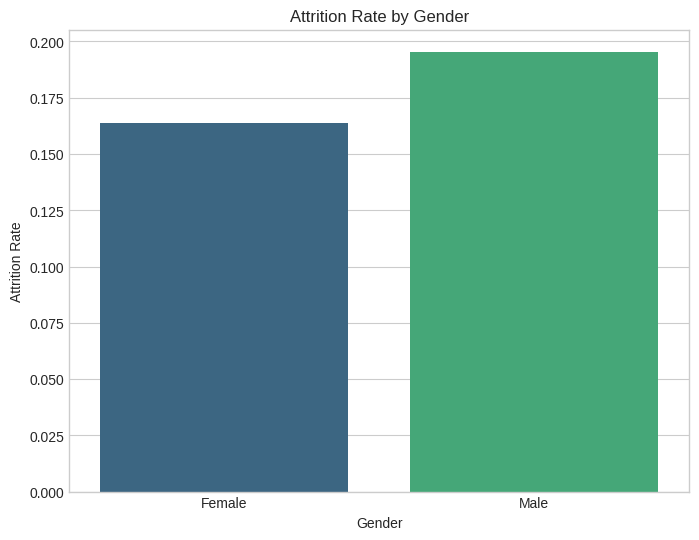

In [17]:
plt.figure(figsize=(8, 6))
sns.barplot(data=grouped_attrition.groupby('Gender')['Attrition'].mean().reset_index(), x='Gender', y='Attrition', hue='Gender', palette='viridis', legend=False)
plt.title('Attrition Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Attrition Rate')
plt.show()

Following the previous step of visualizing attrition by gender, I will now create a bar plot to show the attrition rate by 'MaritalStatus' to observe how attrition varies among different marital statuses.



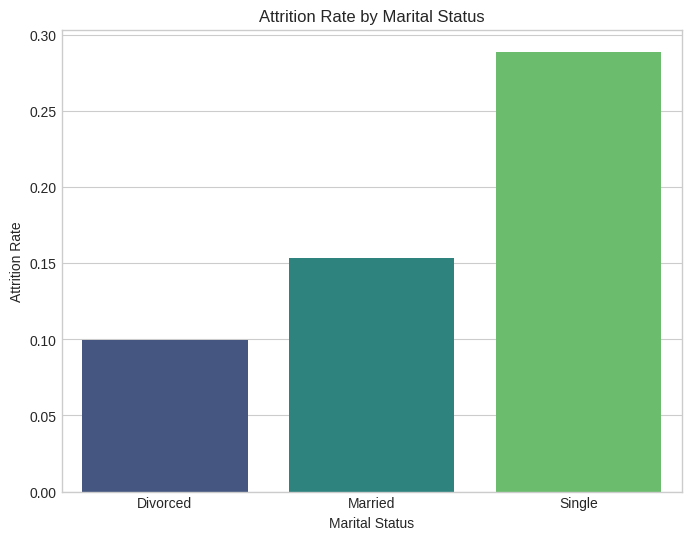

In [18]:
plt.figure(figsize=(8, 6))
sns.barplot(data=grouped_attrition.groupby('MaritalStatus')['Attrition'].mean().reset_index(), x='MaritalStatus', y='Attrition', hue='MaritalStatus', palette='viridis', legend=False)
plt.title('Attrition Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Attrition Rate')
plt.show()

Continuing the visualization of attrition rates, I will now create a bar plot to show attrition by 'Education' level to understand if education influences an employee's likelihood to leave the company.



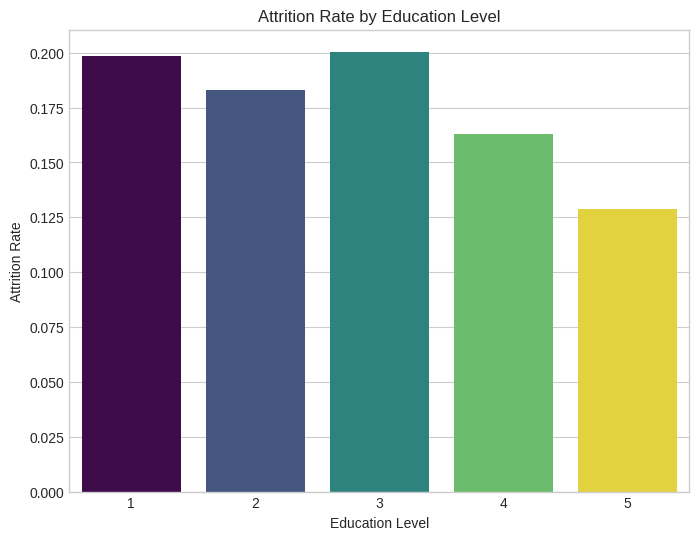

In [19]:
plt.figure(figsize=(8, 6))
sns.barplot(data=grouped_attrition.groupby('Education')['Attrition'].mean().reset_index(), x='Education', y='Attrition', hue='Education', palette='viridis', legend=False)
plt.title('Attrition Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Attrition Rate')
plt.show()

Next, I will create a bar plot to visualize the attrition rate by 'EducationField' to explore how different educational backgrounds might correlate with attrition.



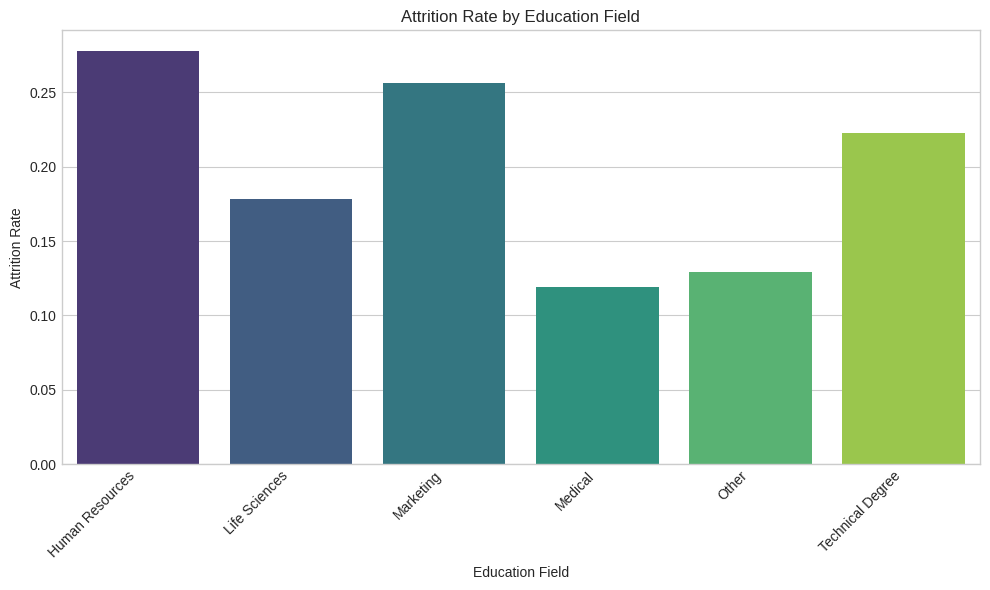

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_attrition.groupby('EducationField')['Attrition'].mean().reset_index(), x='EducationField', y='Attrition', hue='EducationField', palette='viridis', legend=False)
plt.title('Attrition Rate by Education Field')
plt.xlabel('Education Field')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Continuing the visualization, I will now create a bar plot to show the attrition rate by 'AgeGroup' to understand if certain age brackets are more susceptible to attrition.



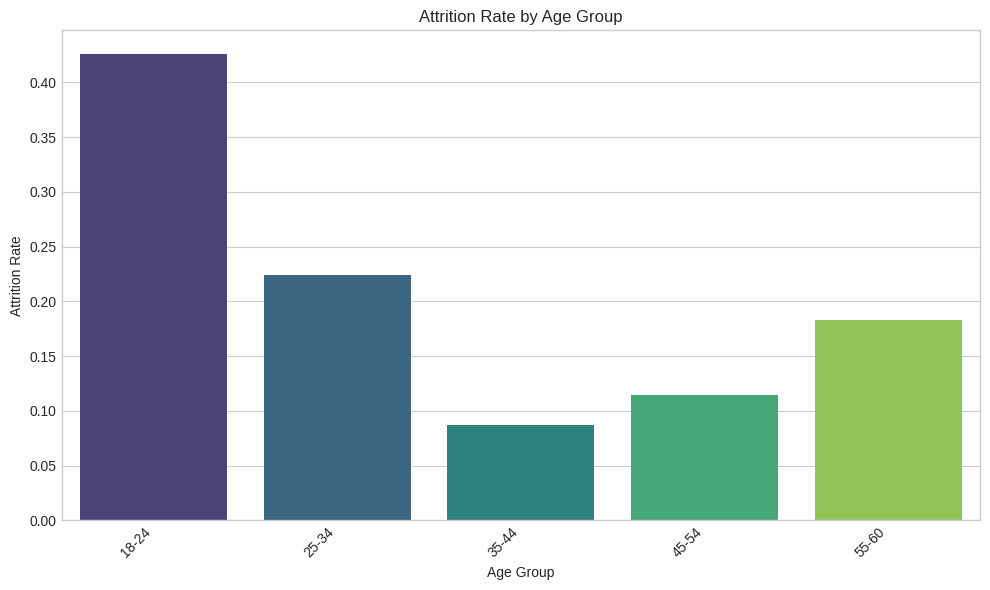

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_attrition.groupby('AgeGroup', observed=False)['Attrition'].mean().reset_index(), x='AgeGroup', y='Attrition', hue='AgeGroup', palette='viridis', legend=False)
plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Findings on Demography and Attrition

1.  **Age Distribution**: The 'Age' column shows a mean age of approximately 36.9 years, with a range from 18 to 60. The majority of employees fall within the 25-44 age groups. The 'AgeGroup' bar plot indicates that **younger employees (18-24 and 25-34)** tend to have higher attrition rates compared to older age groups.

2.  **Gender Distribution**: There are more male employees (882) than female employees (588). The bar plot for 'Gender' shows that **male employees** have a slightly higher attrition rate than female employees.

3.  **Marital Status Distribution**: The largest group is 'Married' (673), followed by 'Single' (470) and 'Divorced' (327). The 'MaritalStatus' bar plot clearly indicates that **Single employees** have a significantly higher attrition rate than Married or Divorced employees.

4.  **Education Level Distribution**: Education levels range from 1 to 5. The most common education levels are 3 and 4. The 'Education' bar plot underlines that **employees with education levels 1 and 2**, have slightly higher attrition rates, underlining a surprising trend that with lower education level people are more prone to attrition.

5.  **Education Field Distribution**: 'Life Sciences' and 'Medical' are the most common education fields. The 'EducationField' bar plot reveals that employees from 'Human Resources' and 'Technical Degree' fields exhibit **higher attrition rates** compared to other fields like 'Life Sciences' or 'Medical'.

**Demographic groups more prone to attrition**:
*   **Younger employees** (especially those in the 18-24 and 25-34 age brackets).
*   **Single employees**.
*   **Male employees** (to a lesser extent).
*   Employees with an educational background in **Human Resources** or **Technical Degree**.
*   Potentially, employees with **lower education levels**.

These findings suggest that a targeted approach focusing on these specific demographic segments might be beneficial for retention strategies.

# Organizational Information

In [22]:
features = ["Department", "JobRole", "JobLevel", "JobInvolvement", "BusinessTravel"]

def attrition_rate_table(df, col):
    """Returns counts + attrition rate by group."""
    grp = df.groupby(col)["Attrition"]
    out = pd.DataFrame({
        "count": grp.size(),
        "attritions": grp.sum(),
        "attrition_rate": grp.mean()
    }).sort_values("attrition_rate", ascending=False)
    return out

for col in features:
    print(f"\n=== {col} ===")
    display(attrition_rate_table(df, col))


=== Department ===


,count,attritions,attrition_rate
Department,,,
Sales,446,92,0.206278
Human Resources,63,12,0.190476
Research & Development,961,133,0.138398



=== JobRole ===


,count,attritions,attrition_rate
JobRole,,,
Sales Representative,83,33,0.397590
Laboratory Technician,259,62,0.239382
Human Resources,52,12,0.230769
Sales Executive,326,57,0.174847
Research Scientist,292,47,0.160959
Manufacturing Director,145,10,0.068966
Healthcare Representative,131,9,0.068702
Manager,102,5,0.049020
Research Director,80,2,0.025000



=== JobLevel ===


,count,attritions,attrition_rate
JobLevel,,,
1,543,143,0.263352
3,218,32,0.146789
2,534,52,0.097378
5,69,5,0.072464
4,106,5,0.047170



=== JobInvolvement ===


,count,attritions,attrition_rate
JobInvolvement,,,
1,83,28,0.337349
2,375,71,0.189333
3,868,125,0.144009
4,144,13,0.090278



=== BusinessTravel ===


,count,attritions,attrition_rate
BusinessTravel,,,
Travel_Frequently,277,69,0.249097
Travel_Rarely,1043,156,0.149569
Non-Travel,150,12,0.080000


Listing the department and job roles in this form helps to visualize the attrition rate in a different way. It shows the department and job roles that have the highest attrition on the top and the lowest and the bottom. By seeing the counts it helps also to determine whethe we are talking about a lot of workers or relatively few. This can be helpful when trying to decide from where to start analyzing, and in this case it seems like looking closer to sales makes sense.

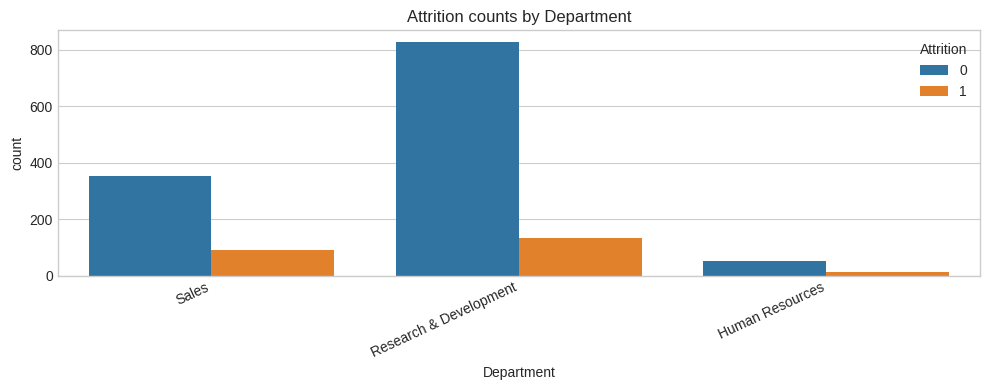

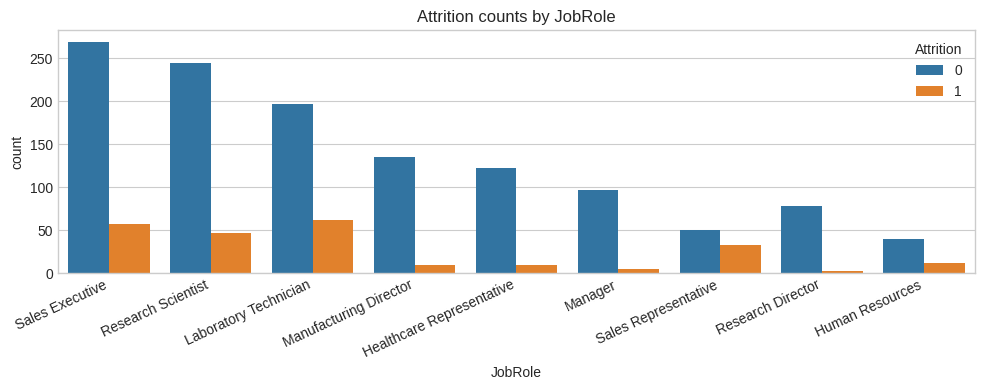

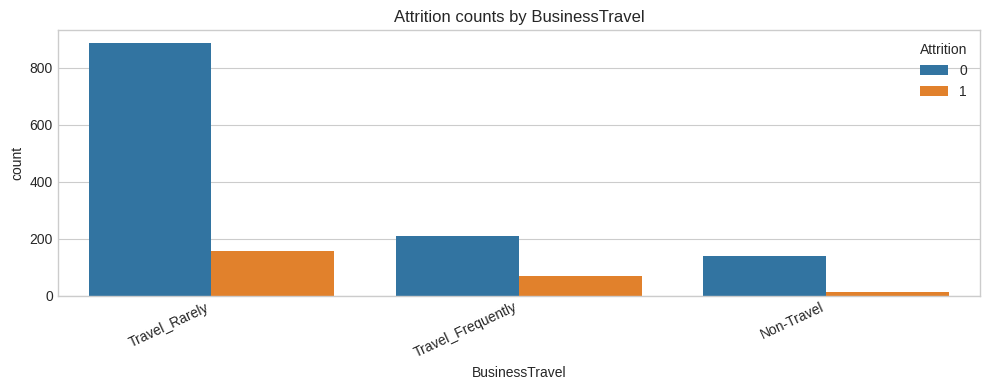

In [23]:
for col in ["Department", "JobRole", "BusinessTravel"]:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue="Attrition")
    plt.title(f"Attrition counts by {col}")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

Attrition is strongly role and hierarchy dependent. Frontline roles such as Sales Representatives exhibit extremely high turnover while senior leadership roles show remarkable stability. Job level demonstrates a clear inverse relationship with attrition, suggesting promotion and compensation act as retention mechanisms.

Additionally, high business travel frequency and low job involvement significantly elevate turnover risk. Overall, attrition appears structurally concentrated among early-career, lower-level, high-pressure positions rather than being uniformly distributed across the organization.


% Calculation

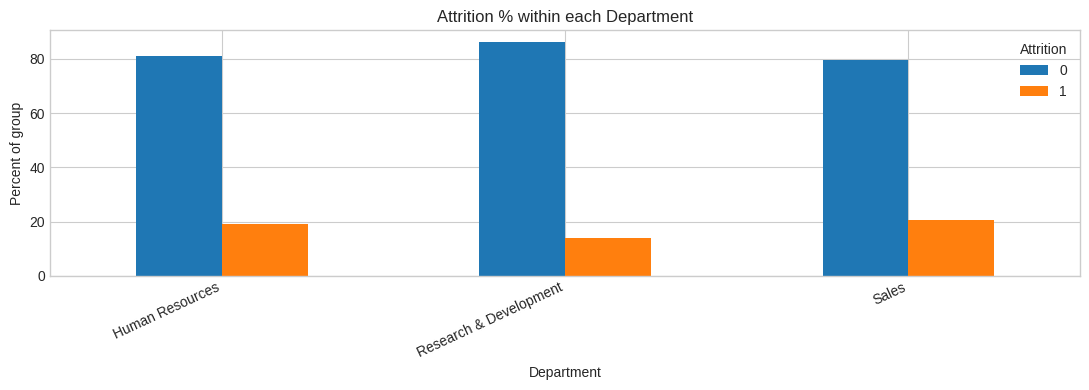

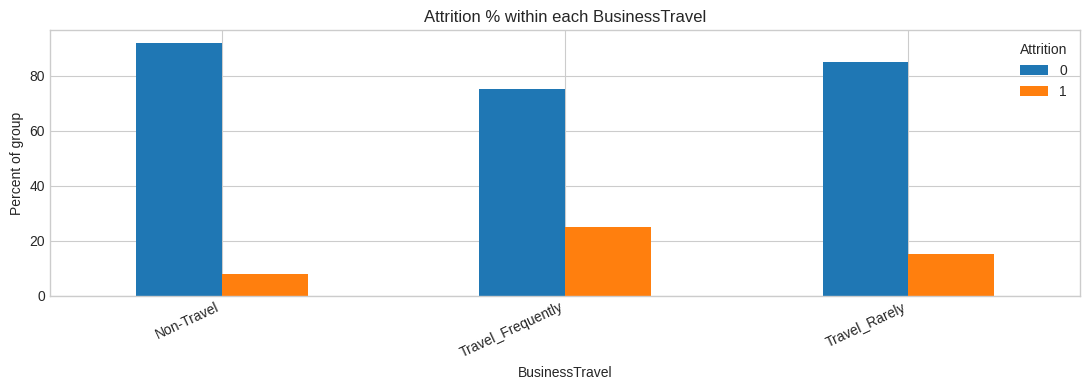

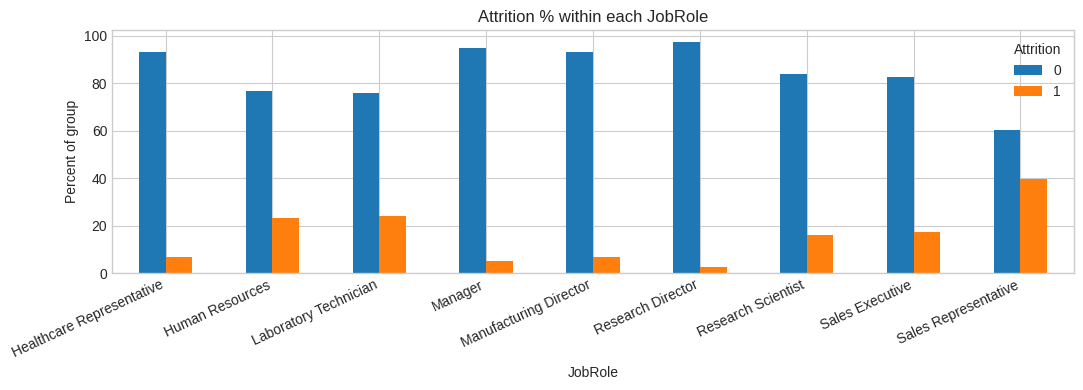

In [24]:
for col in ["Department", "BusinessTravel", "JobRole"]:
    ct = pd.crosstab(df[col], df["Attrition"], normalize="index") * 100
    ct = ct[["No", "Yes"]] if set(["No","Yes"]).issubset(ct.columns) else ct

    ax = ct.plot(kind="bar", figsize=(11, 4))
    plt.title(f"Attrition % within each {col}")
    plt.ylabel("Percent of group")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Attrition")
    plt.tight_layout()
    plt.show()

Among all job roles, Sales Representatives exhibit the highest attrition rate by a substantial margin, making it the most distinct turnover hotspot in the organization. The magnitude of the difference would indicate that role specific factors, such as performance pressure, travel demands, or commission-based compensation, could significantly contribute to exit decisions.

Travel in itself seems to be a cause for attrition as well. This would make sense as it can be draining to have to travel for work, and such workers might want to move to non-traveling jobs.

# Compensation and benefit analysis

In [25]:
df['MonthlyRate'].describe()

,MonthlyRate
count,1470.000000
mean,14313.103401
std,7117.786044
min,2094.000000
25%,8047.000000
50%,14235.500000
75%,20461.500000
max,26999.000000


In [26]:
# Create the compensation_subset with requested columns
compensation_subset = df[['StockOptionLevel', 'PercentSalaryHike', 'MonthlyIncome', 'Attrition']].copy()

# Define bins and labels for MonthlyIncome
min_income = compensation_subset['MonthlyIncome'].min()
max_income = compensation_subset['MonthlyIncome'].max()
bins = [min_income, 3000, 5000, 8000, max_income + 1] # Ensure all values are covered
labels = ['<3000', '3000-5000', '5000-8000', '>8000']

# Create the new 'MonthlyIncome_grouped' column
compensation_subset['MonthlyIncome_grouped'] = pd.cut(compensation_subset['MonthlyIncome'], bins=bins, labels=labels, right=False)

print("First 5 rows of compensation_subset with new income groups:\n")
display(compensation_subset.head())

print("\nValue counts for 'MonthlyIncome_grouped' in compensation_subset:\n")
print(compensation_subset['MonthlyIncome_grouped'].value_counts().sort_index())

First 5 rows of compensation_subset with new income groups:



,StockOptionLevel,PercentSalaryHike,MonthlyIncome,Attrition,MonthlyIncome_grouped
0,0,11,5993,1,5000-8000
1,1,23,5130,0,5000-8000
2,0,15,2090,1,<3000
3,0,11,2909,0,<3000
4,1,12,3468,0,3000-5000



Value counts for 'MonthlyIncome_grouped' in compensation_subset:

MonthlyIncome_grouped
<3000        395
3000-5000    354
5000-8000    340
>8000        381
Name: count, dtype: int64


By grouping the salaries to these groups (based on the percentage groups from describe function) allows a clearner and easier analysis of monthly income and its relationship with attrition.

In [27]:
features = ["StockOptionLevel", "PercentSalaryHike", "MonthlyIncome_grouped"]

def attrition_rate_table(df, col):
    """Returns counts + attrition rate by group."""
    grp = compensation_subset.groupby(col)["Attrition"]
    out = pd.DataFrame({
        "count": grp.size(),
        "attritions": grp.sum(),
        "attrition_rate": grp.mean()
    }).sort_values("attrition_rate", ascending=False)
    return out

for col in features:
    print(f"\n=== {col} ===")
    display(attrition_rate_table(df, col))


=== StockOptionLevel ===


,count,attritions,attrition_rate
StockOptionLevel,,,
0,631,154,0.244057
3,85,15,0.176471
1,596,56,0.093960
2,158,12,0.075949



=== PercentSalaryHike ===


,count,attritions,attrition_rate
PercentSalaryHike,,,
24,21,6,0.285714
22,56,12,0.214286
23,28,6,0.214286
11,210,41,0.195238
16,78,14,0.179487
15,101,18,0.178218
17,82,14,0.170732
12,198,33,0.166667
13,209,34,0.162679



=== MonthlyIncome_grouped ===


/tmp/ipython-input-1901726556.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = compensation_subset.groupby(col)["Attrition"]


,count,attritions,attrition_rate
MonthlyIncome_grouped,,,
<3000,395,113,0.286076
3000-5000,354,50,0.141243
>8000,381,40,0.104987
5000-8000,340,34,0.100000


Stock option allocation demonstrates a strong inverse relationship with attrition, with employees lacking equity participation exhibiting significantly higher turnover rates. In contrast percent salary hike is suggesting that short-term compensation adjustments may be less effective than long-term incentive alignment.

These findings imply that structural incentive design, particularly equity participation, plays a meaningful role in employee retention.


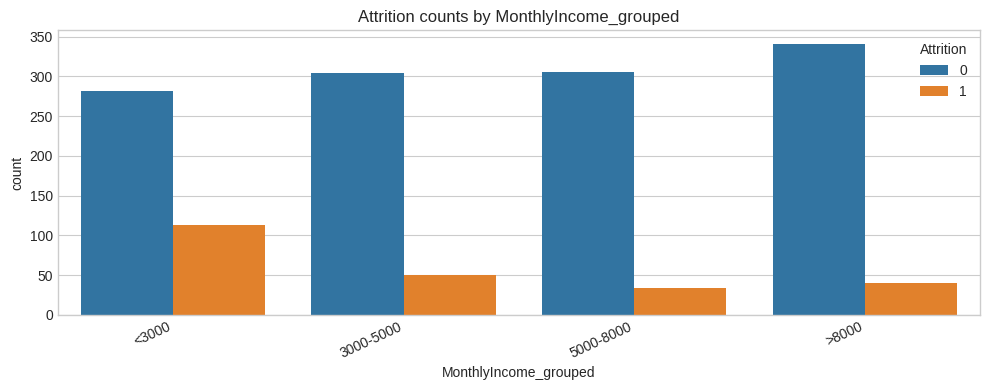

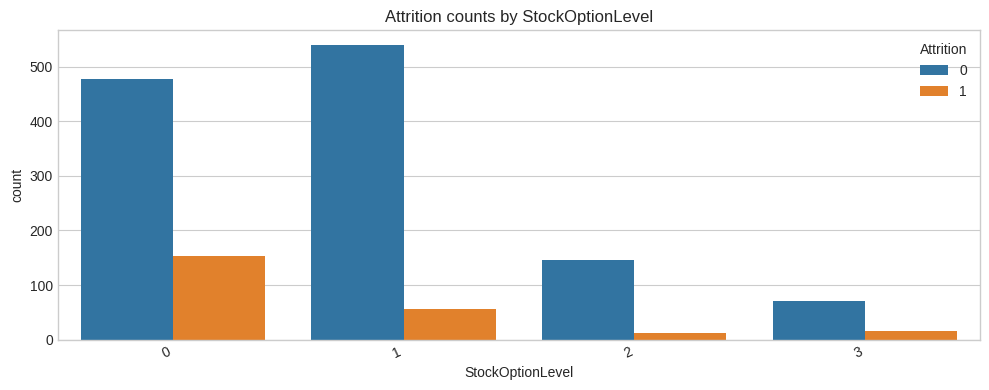

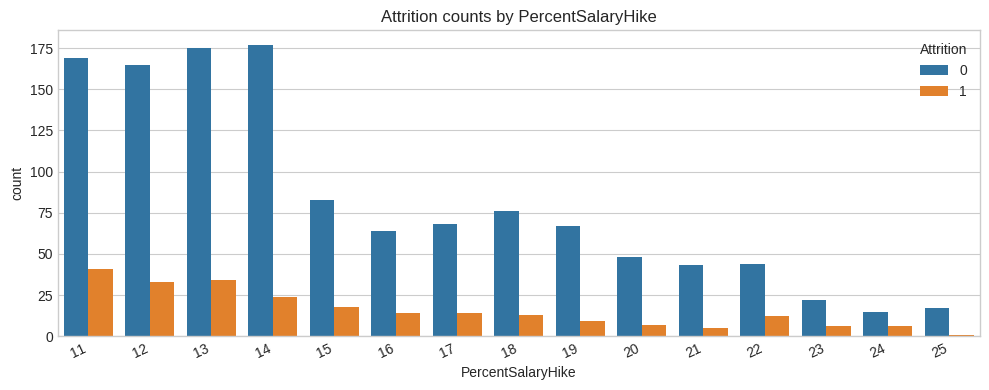

In [28]:
for col in ["MonthlyIncome_grouped", "StockOptionLevel", "PercentSalaryHike"]:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=compensation_subset, x=col, hue="Attrition")
    plt.title(f"Attrition counts by {col}")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

We can see that the monthly income group under 3000 and the stock option group 0 have a higher attrition from these figures.

In [29]:
num_cols = [
    "MonthlyIncome", "HourlyRate", "DailyRate", "MonthlyRate",
    "StockOptionLevel", "PercentSalaryHike"
]

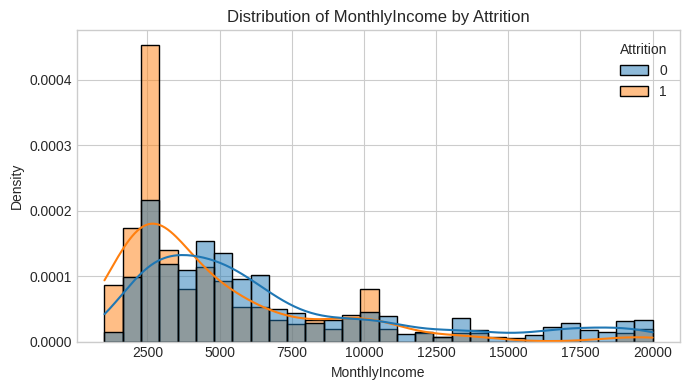

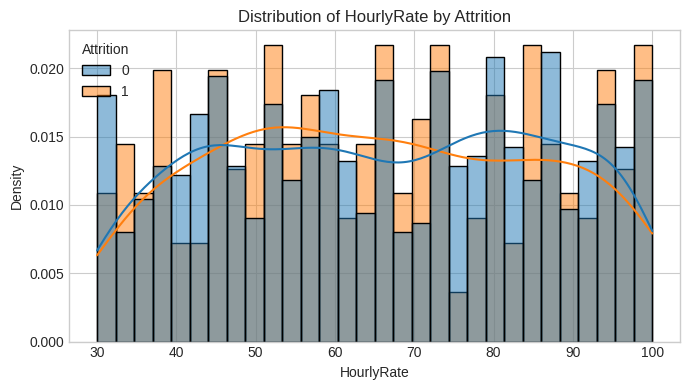

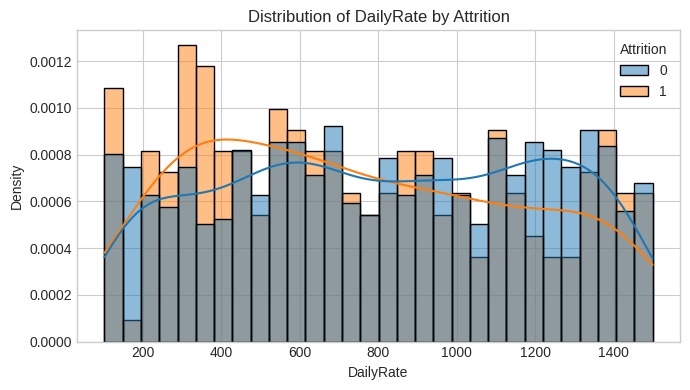

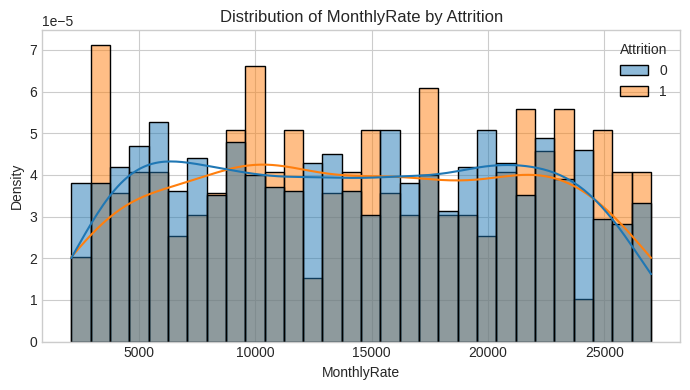

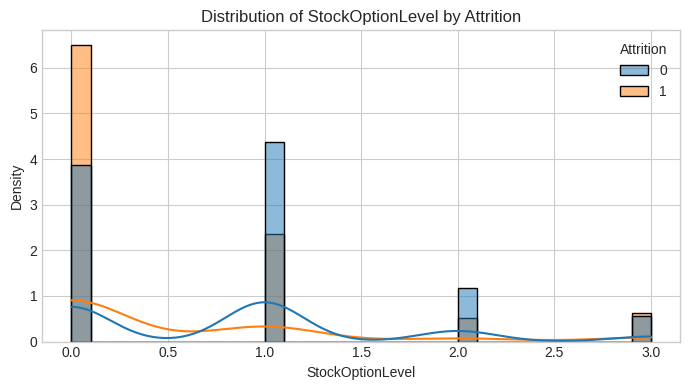

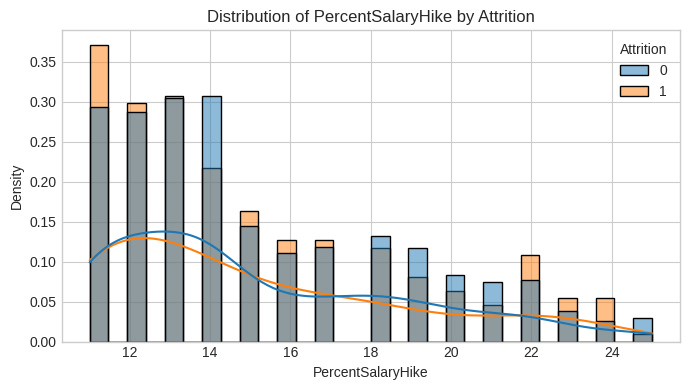

In [30]:
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue="Attrition", kde=True, stat="density", common_norm=False, bins=30)
    plt.title(f"Distribution of {col} by Attrition")
    plt.tight_layout()
    plt.show()

Here we can see rather clearly the orange in the back identifying the more attrition prone categories. Lower monthly income and no stock option groups are the ones again that show a higher attrition.

One more different way to visualize this is to use 5 quantile-based bins.

/tmp/ipython-input-889463111.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(bins)["Attrition"].mean()


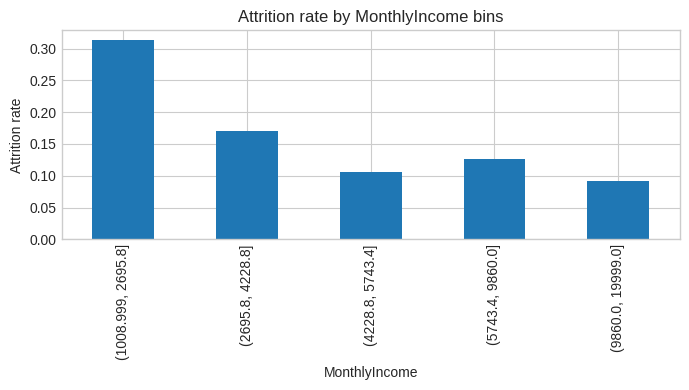

/tmp/ipython-input-889463111.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(bins)["Attrition"].mean()


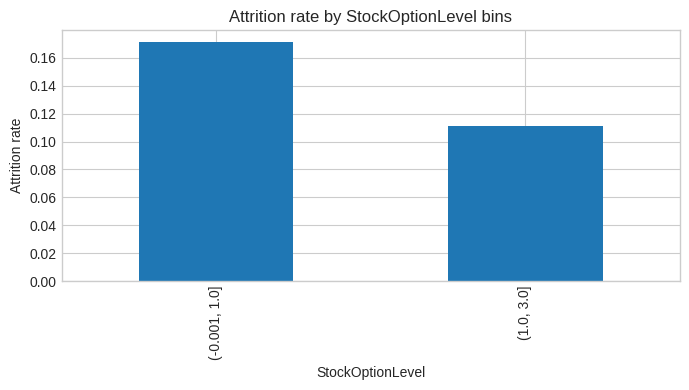

/tmp/ipython-input-889463111.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(bins)["Attrition"].mean()


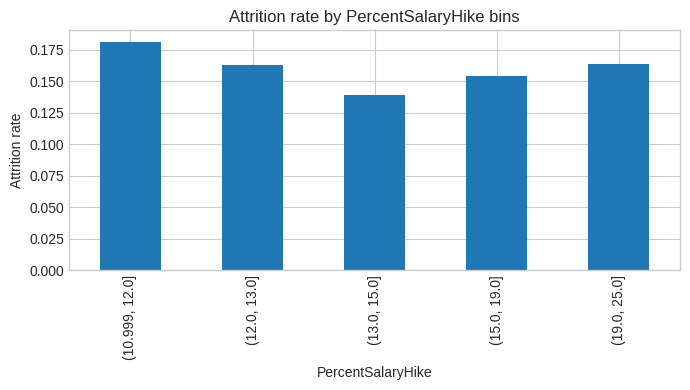

In [31]:
for col in ["MonthlyIncome", "StockOptionLevel", "PercentSalaryHike"]:
    # qcut can fail if many duplicates; fall back to cut
    try:
        bins = pd.qcut(df[col], q=5, duplicates="drop")
    except ValueError:
        bins = pd.cut(df[col], bins=5)

    rate = df.groupby(bins)["Attrition"].mean()

    plt.figure(figsize=(7, 4))
    rate.plot(kind="bar")
    plt.title(f"Attrition rate by {col} bins")
    plt.ylabel("Attrition rate")
    plt.tight_layout()
    plt.show()

# Satisfaction and Performance Metrics Analysis

* JobSatisfaction: Job satisfaction (1: Low, 2: Medium, 3: High, 4: Very High).
* EnvironmentSatisfaction: Satisfaction with work environment (1–4).
* RelationshipSatisfaction: Satisfaction with workplace relationships (1–4).
* WorkLifeBalance: Perceived work-life balance (1: Bad, 2: Good, 3: Better, 4: Best).
* PerformanceRating: Performance evaluation (3: Good, 4: Excellent).

In [32]:
#Y = df[['Attrition']].copy()
satisfaction_subset = df[['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'PerformanceRating', 'Attrition']].copy()
satisfaction_subset.head()

,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,PerformanceRating,Attrition
0,4,2,1,1,3,1
1,2,3,4,3,4,0
2,3,4,2,3,3,1
3,3,4,3,3,3,0
4,2,1,4,3,3,0


### Distribution

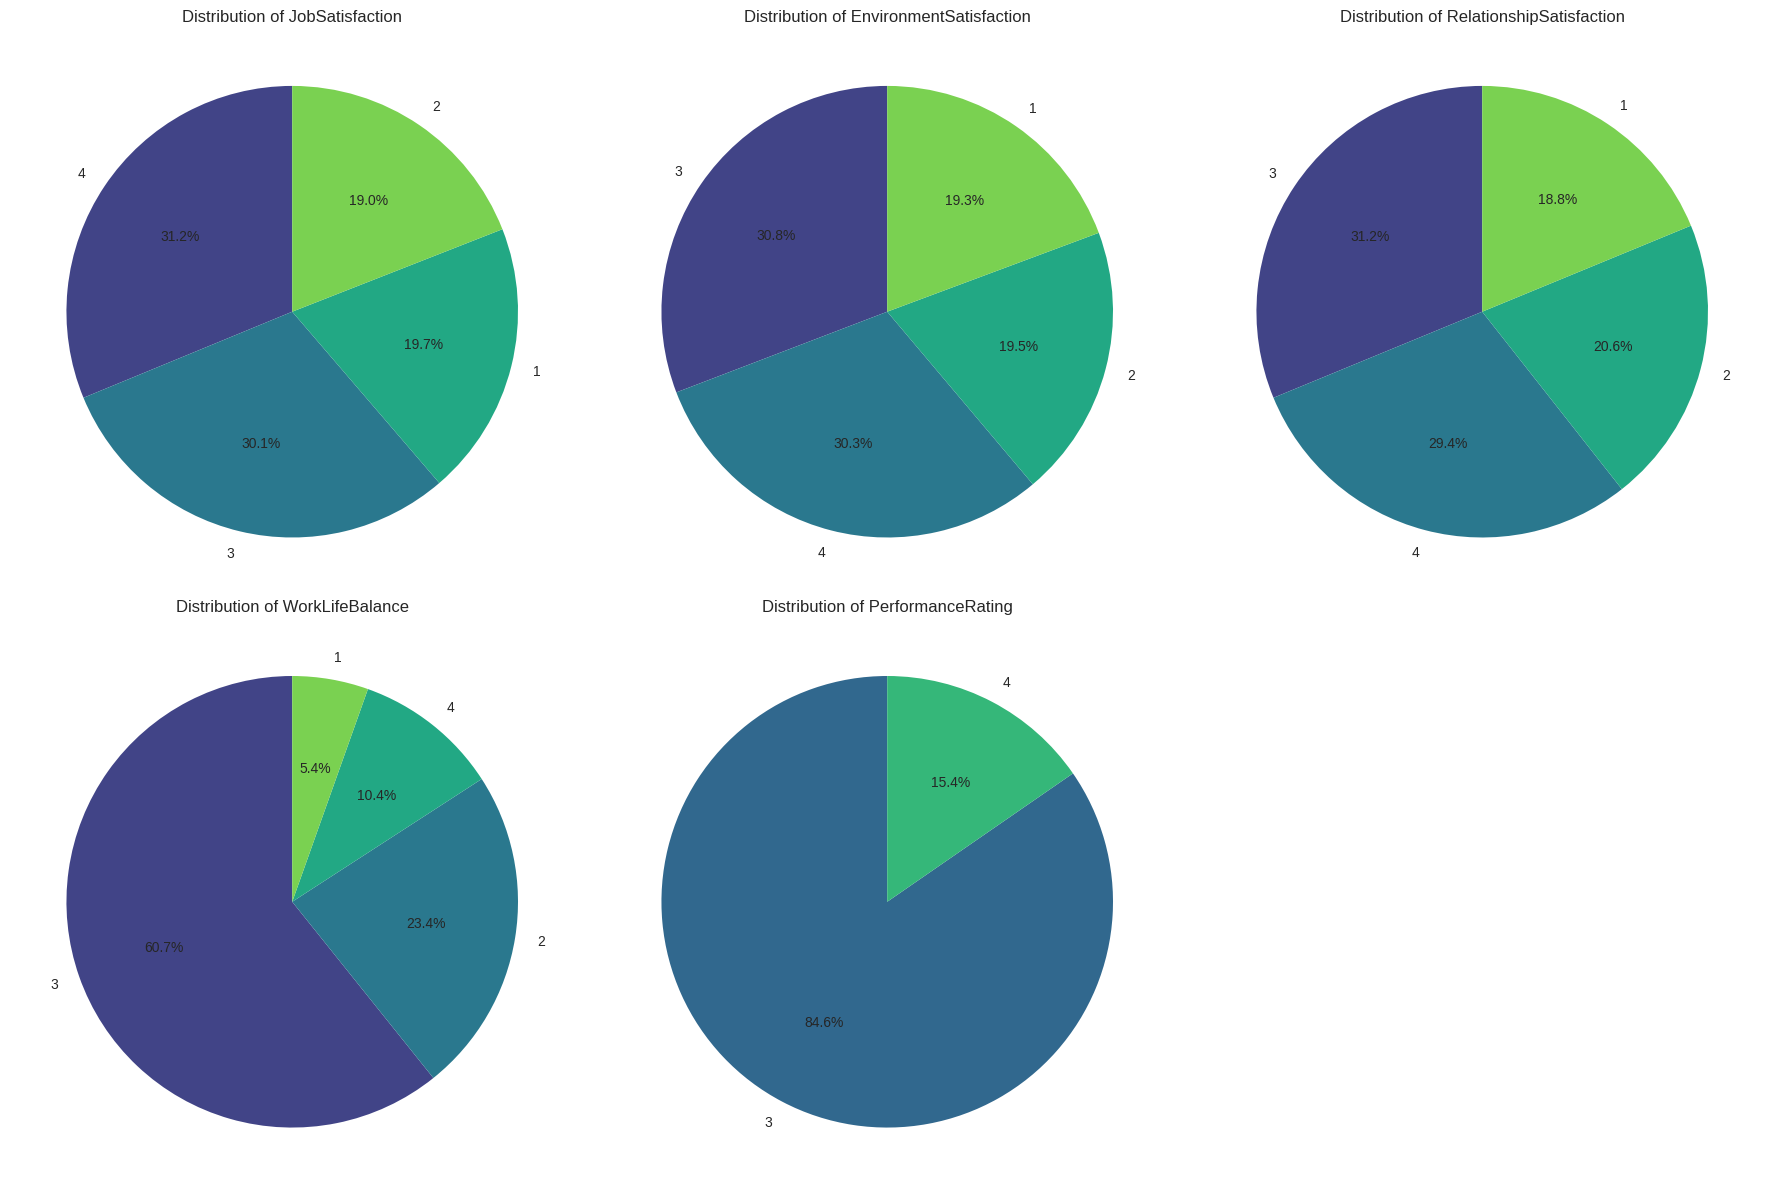

In [33]:
satisfaction_columns = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'PerformanceRating']

num_charts = len(satisfaction_columns)
charts_per_row = 3
num_rows = (num_charts + charts_per_row - 1) // charts_per_row

fig, axes = plt.subplots(num_rows, charts_per_row, figsize=(charts_per_row * 6, num_rows * 6))
axes = axes.flatten() # Flatten the axes array for easy iteration

for i, column in enumerate(satisfaction_columns):
    ax = axes[i]

    # Calculate value counts for the column
    counts = satisfaction_subset[column].value_counts()

    # Plotting the pie chart
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(counts)))
    ax.set_title(f'Distribution of {column}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [34]:
(satisfaction_subset['PerformanceRating'] == 3).sum()

np.int64(1244)

In [35]:
(satisfaction_subset['PerformanceRating'] == 4).sum()

np.int64(226)

### Attrition x Feature

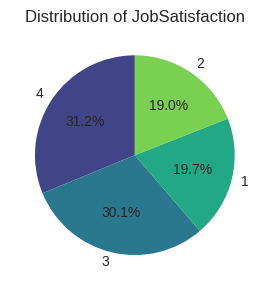

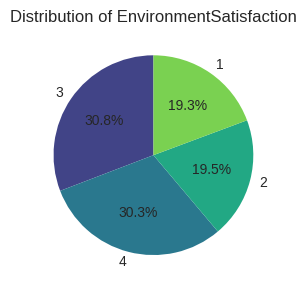

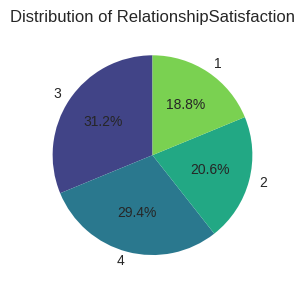

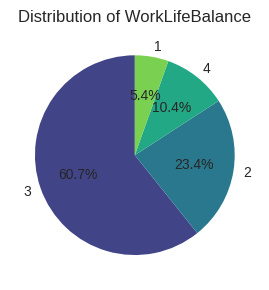

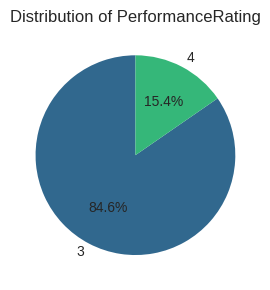

In [36]:
for column in ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'PerformanceRating']:
    plt.figure(figsize=(3, 3))

    # Calculate value counts for the column
    counts = satisfaction_subset[column].value_counts()

    # Plotting the pie chart
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(counts)))
    plt.title(f'Distribution of {column}')
    plt.ylabel('') # Hide default ylabel from pie chart
    plt.tight_layout()
    plt.show()

In [37]:
job_satisfaction_attrition = satisfaction_subset.groupby('JobSatisfaction')['Attrition'].mean().reset_index()
print("Attrition Rate by Job Satisfaction:\n")
print(job_satisfaction_attrition)

Attrition Rate by Job Satisfaction:

   JobSatisfaction  Attrition
0                1   0.228374
1                2   0.164286
2                3   0.165158
3                4   0.113290


**Job Satisfaction**: employees with **low job satisfaction (Level 1)** have a significantly higher attrition rate (approximately 22.8%) compared to those with high job satisfaction (Level 4), whose attrition rate is around 11.3%. This suggests that job dissatisfaction is a major contributor to attrition.

In [38]:
environment_satisfaction_attrition = satisfaction_subset.groupby('EnvironmentSatisfaction')['Attrition'].mean().reset_index()
print("Attrition Rate by Environment Satisfaction:\n")
print(environment_satisfaction_attrition)

Attrition Rate by Environment Satisfaction:

   EnvironmentSatisfaction  Attrition
0                        1   0.253521
1                        2   0.149826
2                        3   0.136865
3                        4   0.134529


**Environment Satisfaction**: employees with **low environment satisfaction (Level 1)** exhibit the highest attrition rate (approximately 25.3%). As environment satisfaction increases, the attrition rate generally decreases, with levels 2, 3, and 4 showing much lower and relatively similar attrition rates (around 13-15%). This highlights the importance of a positive work environment for retention.

In [39]:
relationship_satisfaction_attrition = satisfaction_subset.groupby('RelationshipSatisfaction')['Attrition'].mean().reset_index()
print("Attrition Rate by Relationship Satisfaction:\n")
print(relationship_satisfaction_attrition)

Attrition Rate by Relationship Satisfaction:

   RelationshipSatisfaction  Attrition
0                         1   0.206522
1                         2   0.148515
2                         3   0.154684
3                         4   0.148148


**Relationship Satisfaction**: employees with **low relationship satisfaction (Level 1)** have a higher attrition rate (approximately 20.6%). While levels 2, 3, and 4 have lower attrition rates (around 14-15%), the difference is less pronounced compared to job and environment satisfaction, suggesting it's a factor, but perhaps less impactful than the other two satisfaction metrics.

In [40]:
worklife_balance_attrition = satisfaction_subset.groupby('WorkLifeBalance')['Attrition'].mean().reset_index() # 1: Bad, 2: Good, 3: Better, 4: Best
print("Attrition Rate by Work Life Balance:\n")
print(worklife_balance_attrition)

Attrition Rate by Work Life Balance:

   WorkLifeBalance  Attrition
0                1   0.312500
1                2   0.168605
2                3   0.142217
3                4   0.176471


**Work-Life Balance**: The attrition rate for **poor work-life balance (Level 1)** is notably high (approximately 31.25%). While levels 2, 3, and 4 have lower attrition rates; nevertheless, Level 4 (Best) surprisingly shows a slightly higher attrition rate (17.6%) than Level 3 (Better) (14.2%). This suggests that while a bad work-life balance is a significant attrition driver, the best work-life balance might also indicate other factors at play, or simply a smaller sample size for this group.

In [41]:
performance_rating_attrition = satisfaction_subset.groupby('PerformanceRating')['Attrition'].mean().reset_index() #3 good / 4 excellent
print("Attrition Rate by Performance Rating:\n")
print(performance_rating_attrition)

Attrition Rate by Performance Rating:

   PerformanceRating  Attrition
0                  3   0.160772
1                  4   0.163717


**Performance Rating**: The attrition rates for both performance ratings are very close, indicating that **performance rating does not appear to be a significant predictor of attrition**.

**Key findings for Attrition Risk related to Satisfaction and Performance:**

*   **High Risk**: Employees with low Job Satisfaction (Level 1), low Environment Satisfaction (Level 1), and poor Work-Life Balance (Level 1) are at the highest risk of attrition.

These findings suggest that focusing on improving **job satisfaction**, **environment satisfaction**, and **work-life balance**, especially for those at the lowest levels, could be effective strategies for reducing employee attrition.

# Career History and Workload analysis

* NumCompaniesWorked: Number of previous companies the employee has worked for. Indicates career mobility and experience across organizations.
* TotalWorkingYears: Total number of years the employee has worked in their professional career, across all companies.
* YearsAtCompany: Number of years the employee has worked at the company.
* YearsInCurrentRole: Number of years in the current role.
* YearsSinceLastPromotion: Years since the last promotion.
* YearsWithCurrManager: Years with the current manager.
* TrainingTimesLastYear: Number of training sessions attended in the previous year.
* DistanceFromHome: Distance from home to work (arbitrary units).
* OverTime: Indicates whether the employee works overtime (Yes, No).

In [42]:
#Y = df[['Attrition']].copy()
career_subset = df[['NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TrainingTimesLastYear', 'DistanceFromHome', 'OverTime', 'Attrition']].copy()
career_subset.head()

,NumCompaniesWorked,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear,DistanceFromHome,OverTime,Attrition
0,8,8,6,4,0,5,0,1,Yes,1
1,1,10,10,7,1,7,3,8,No,0
2,6,7,0,0,0,0,3,2,Yes,1
3,1,8,8,7,3,0,3,3,Yes,0
4,9,6,2,2,2,2,3,2,No,0


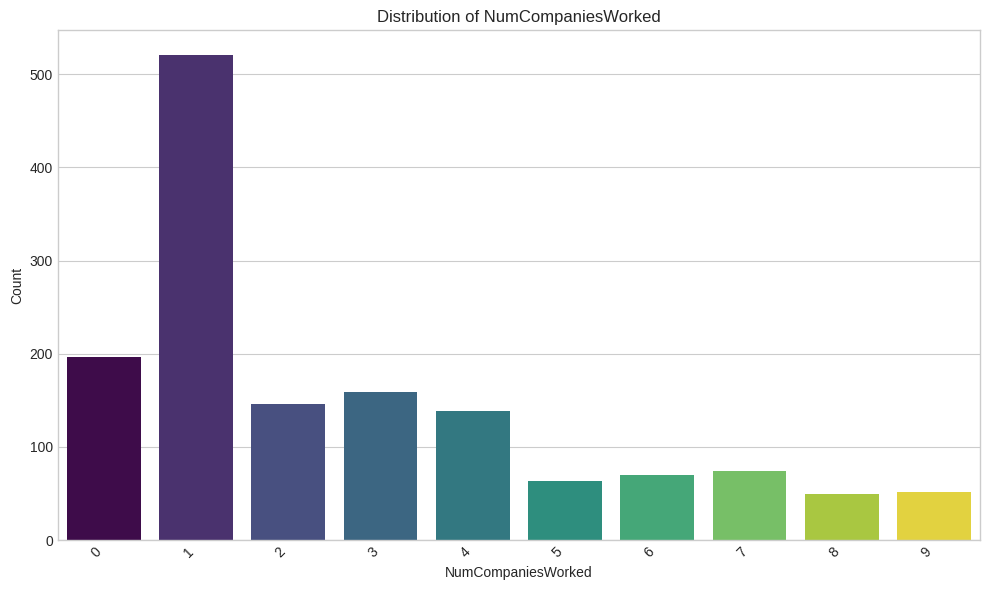

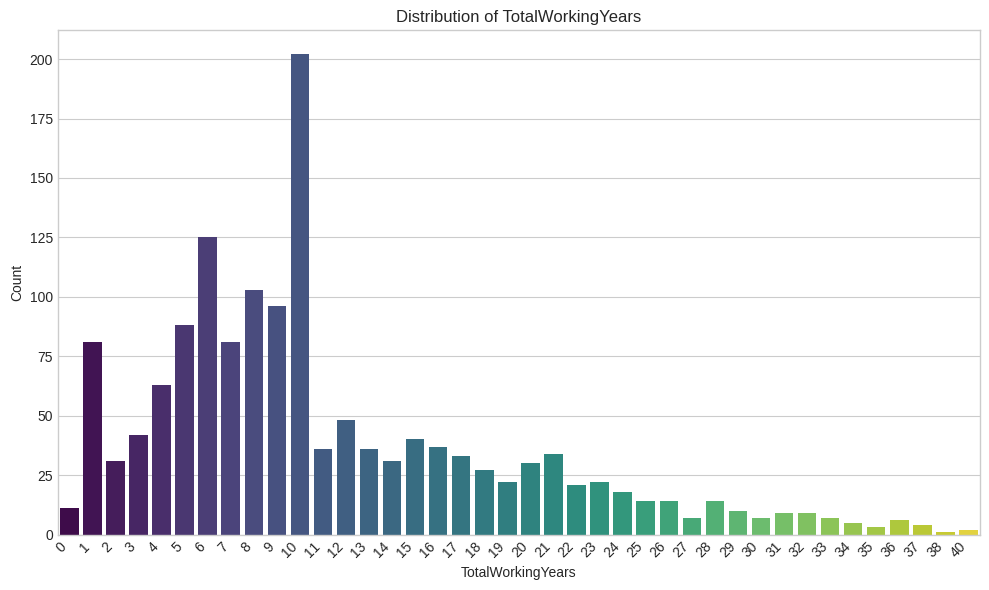

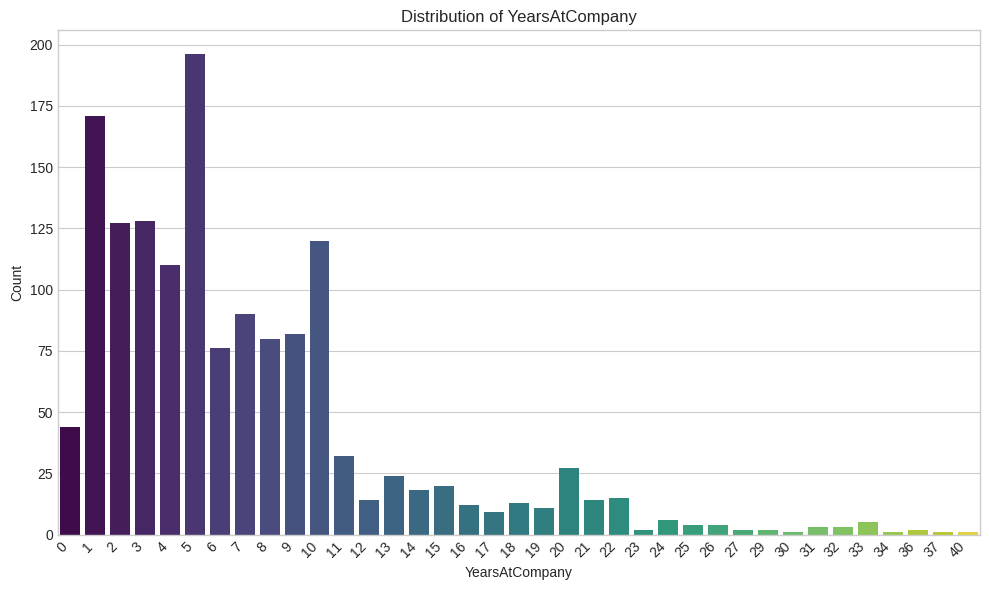

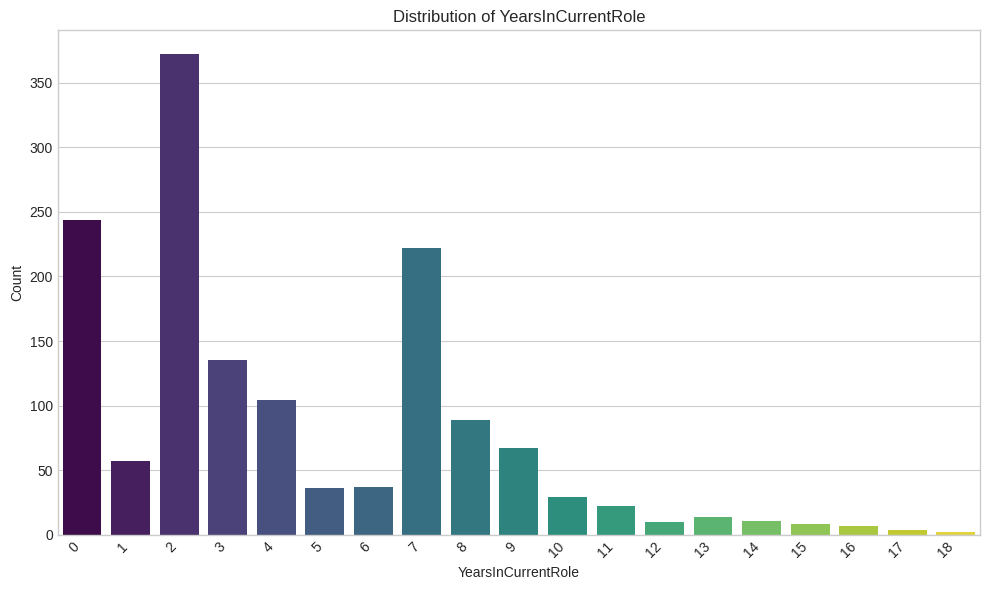

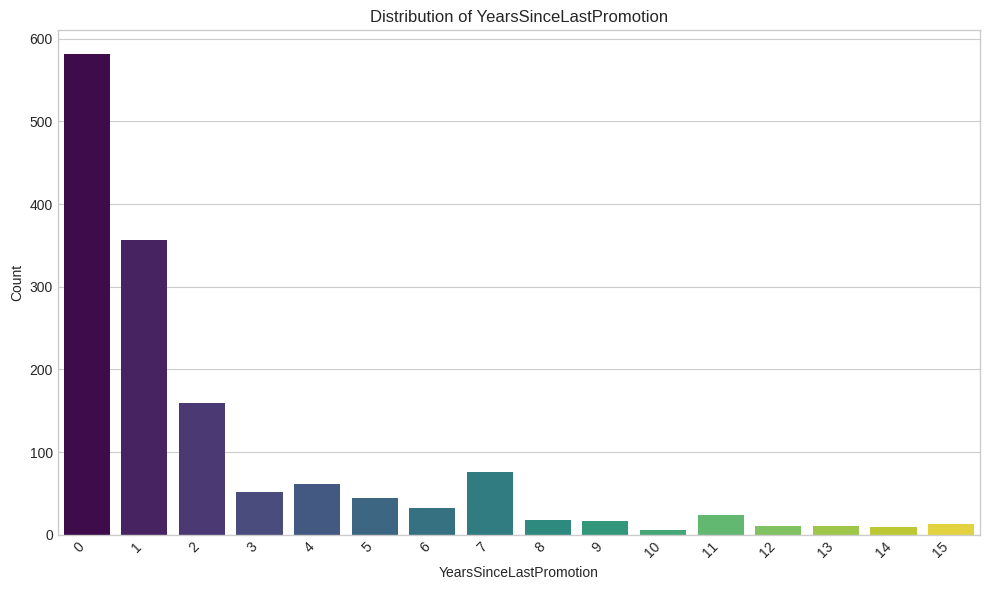

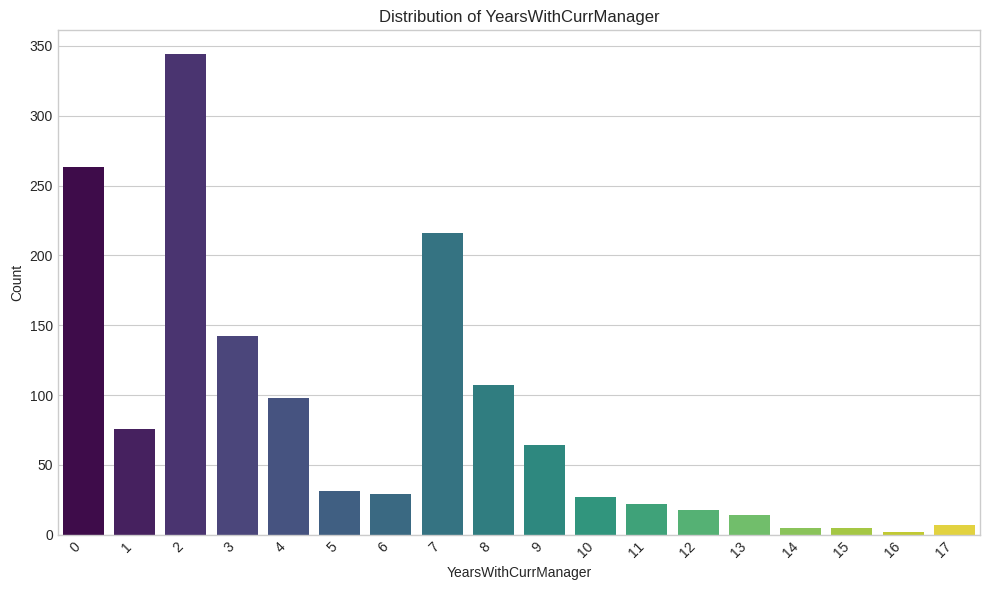

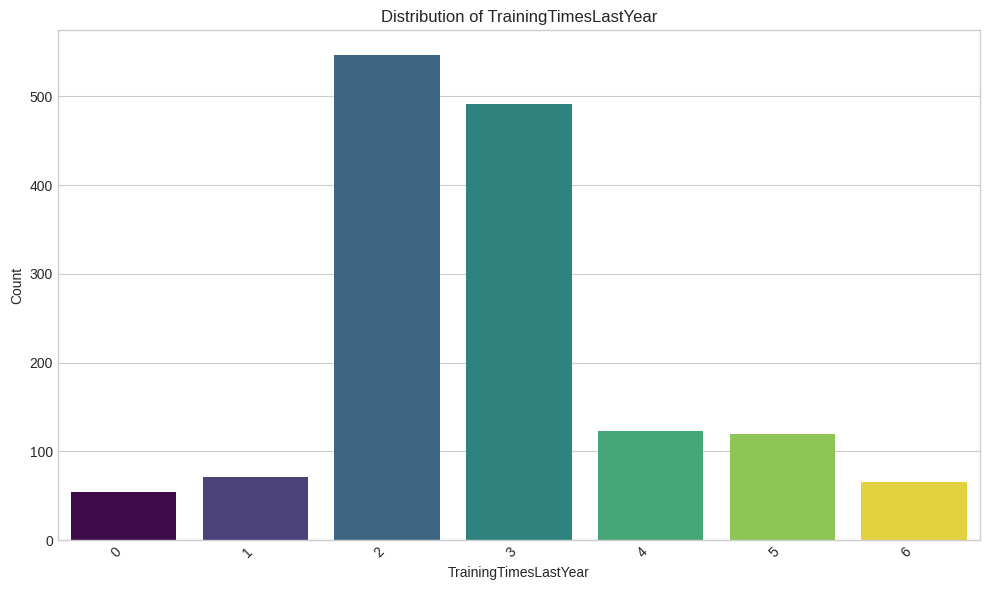

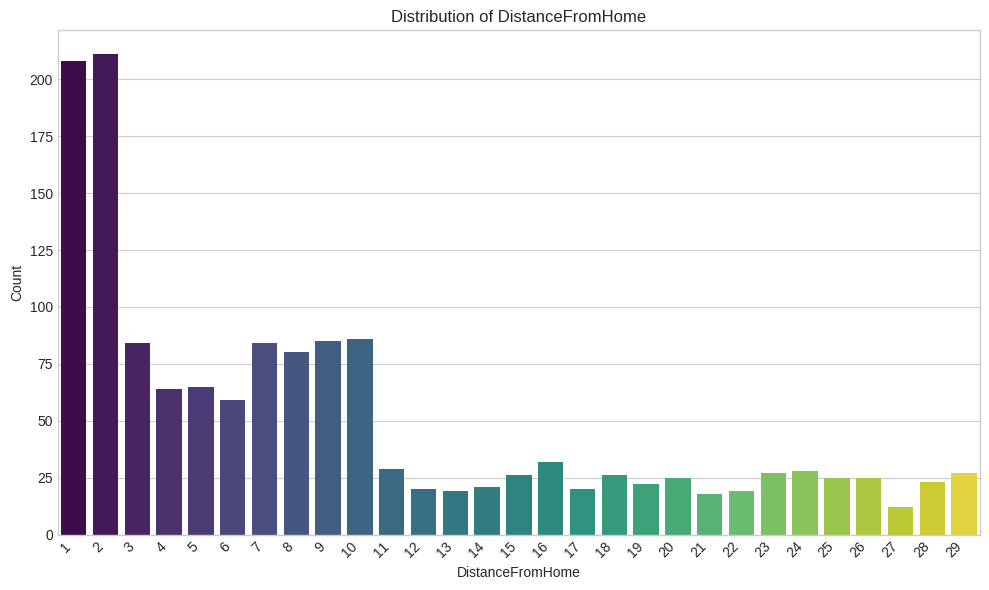

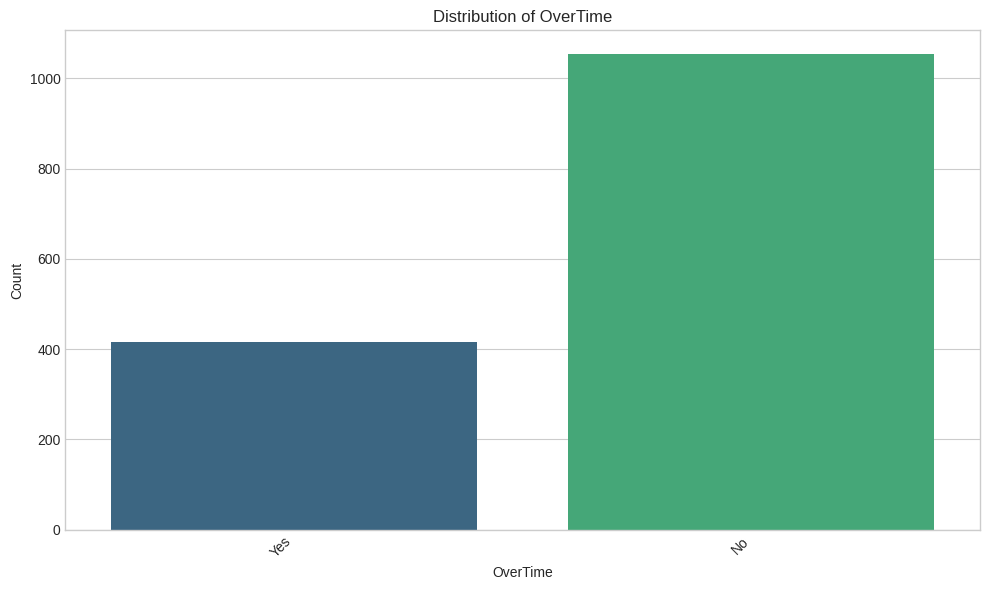

In [43]:
for column in ['NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TrainingTimesLastYear', 'DistanceFromHome', 'OverTime']:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=career_subset, x=column, hue=column, legend=False, palette='viridis')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Now that the distribution plots have been generated, I will calculate the mean attrition rate for each of the specified career history and workload columns by grouping the `career_subset` DataFrame by each column and then taking the mean of the 'Attrition' column. This will prepare the data for the next visualization step.



In [44]:
attrition_by_career_metrics = {}
for column in ['NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TrainingTimesLastYear', 'DistanceFromHome', 'OverTime']:
    grouped_data = career_subset.groupby(column)['Attrition'].mean().reset_index()
    attrition_by_career_metrics[column] = grouped_data
    # print(f"Attrition Rate by {column}:\n")
    # print(grouped_data)
    # print("\n" + "-"*50 + "\n")

Let's see the graphical representation


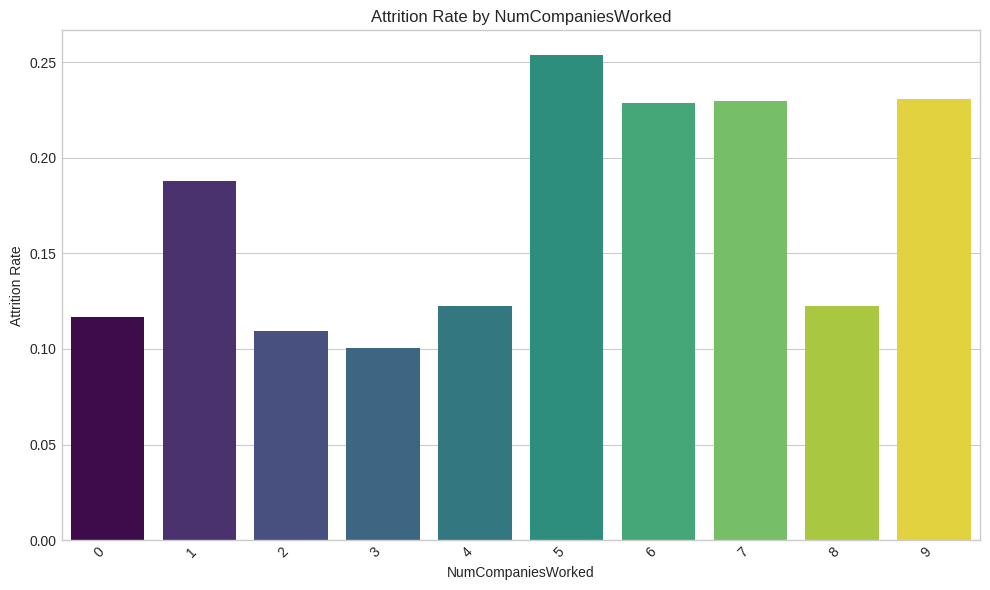

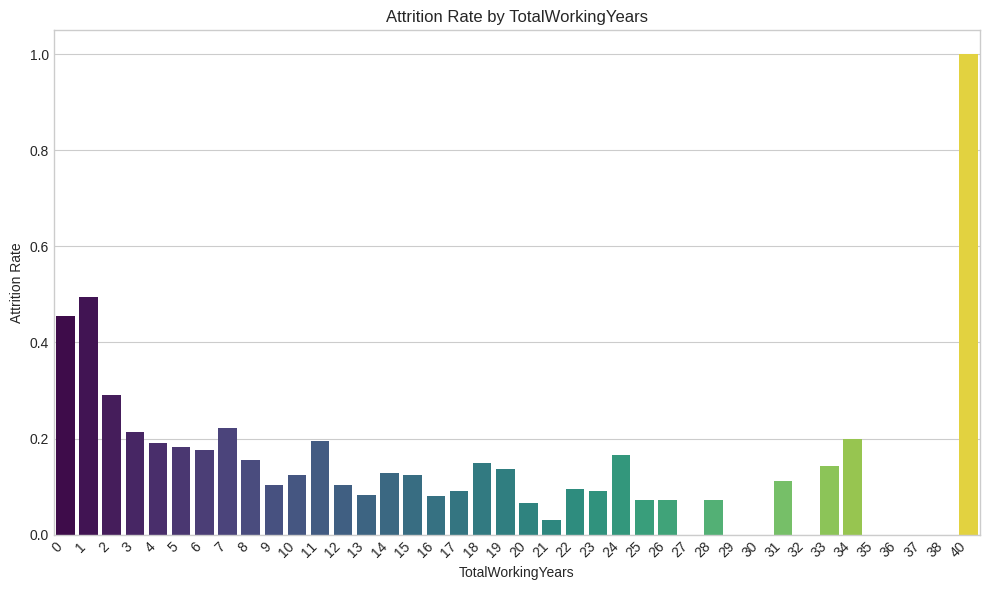

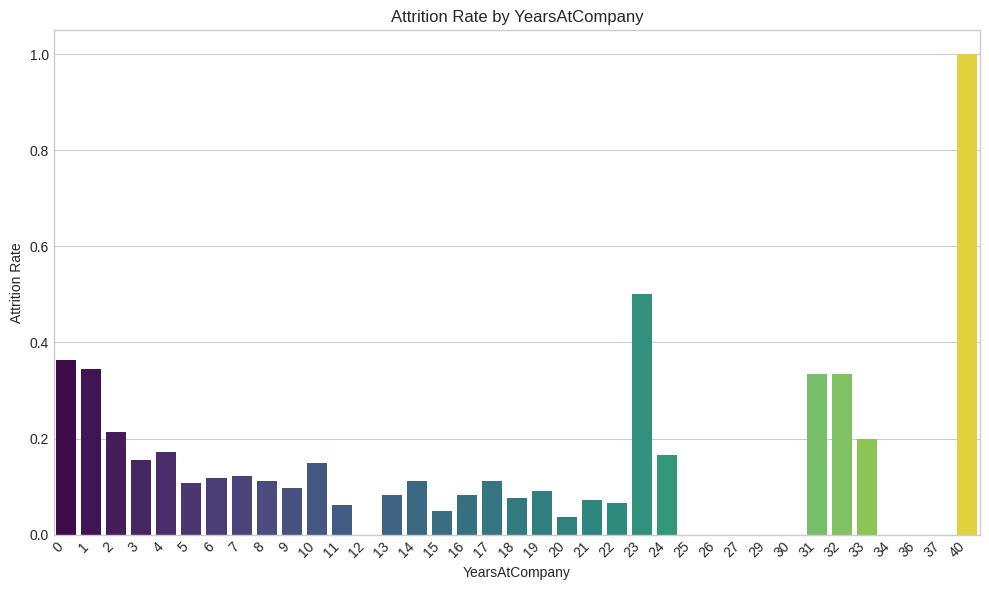

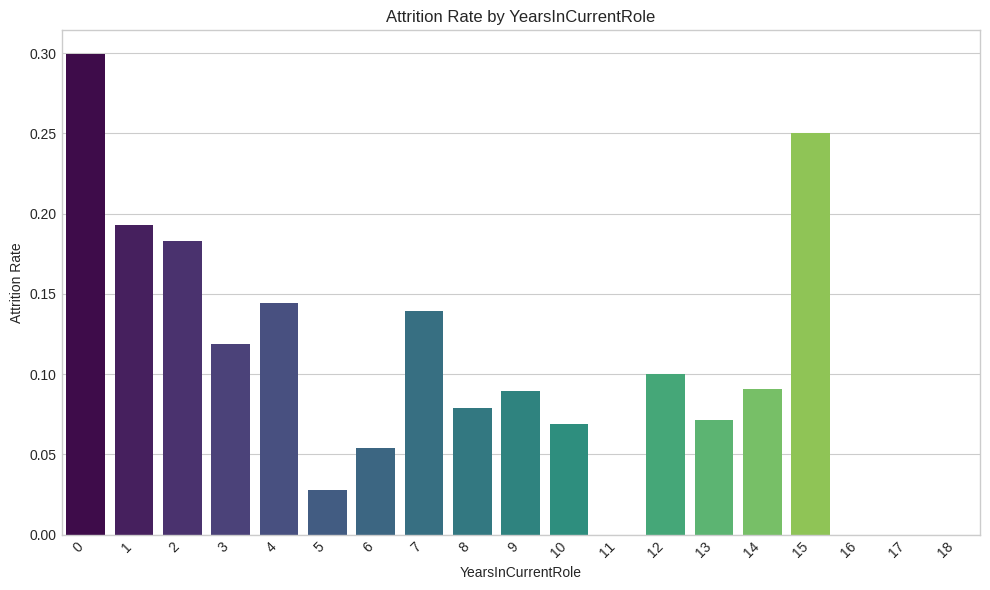

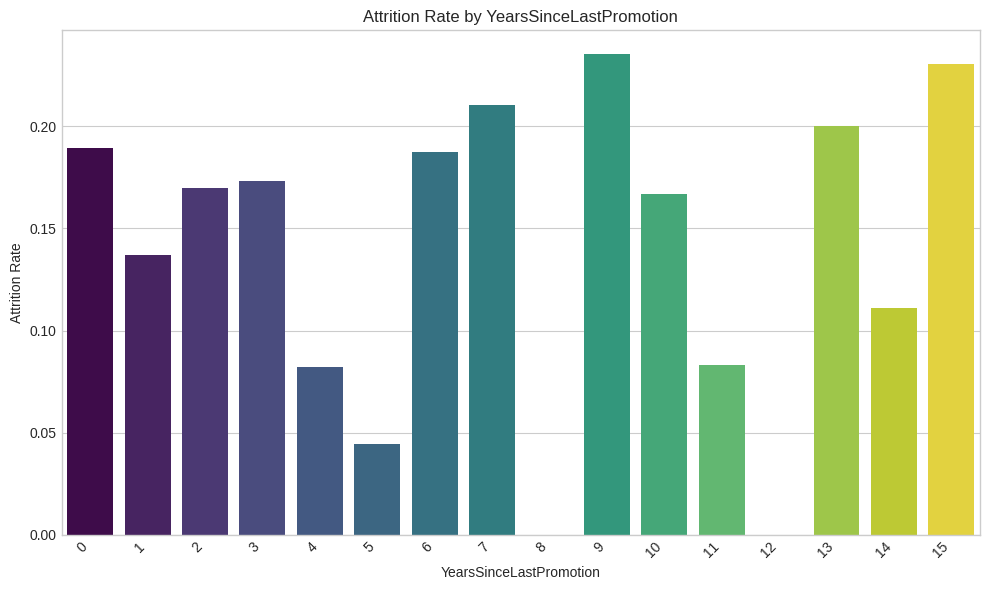

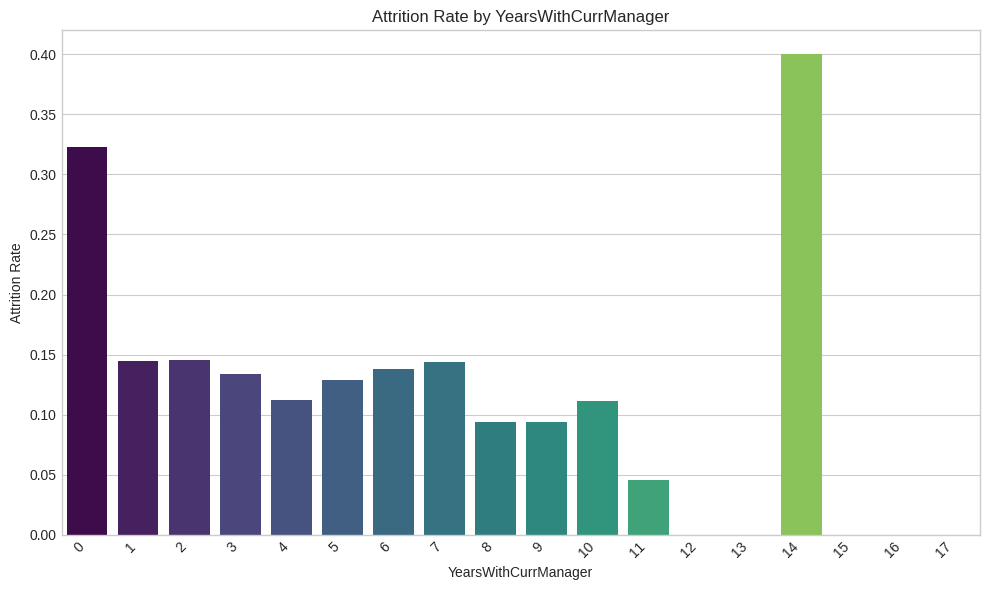

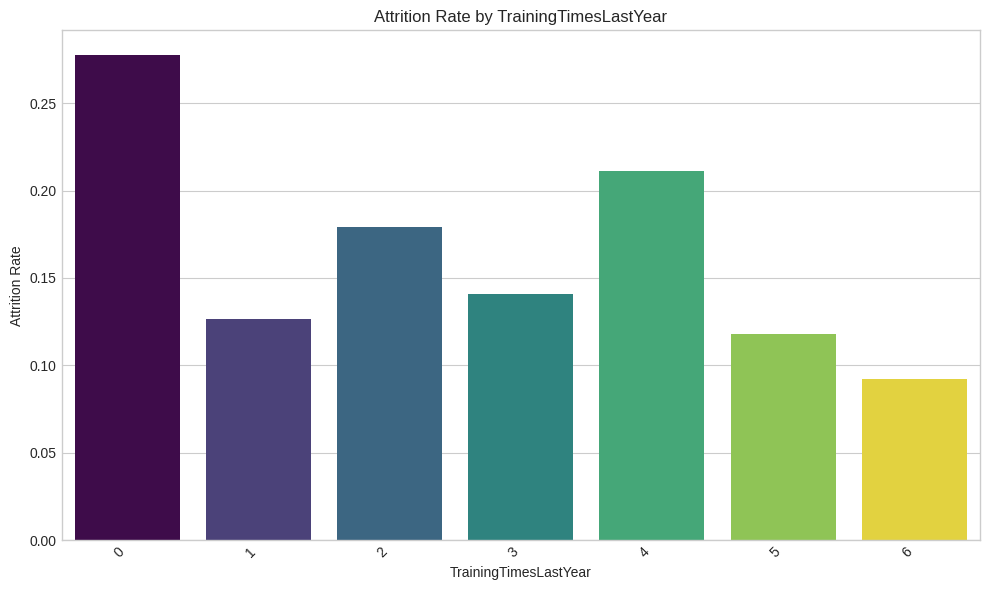

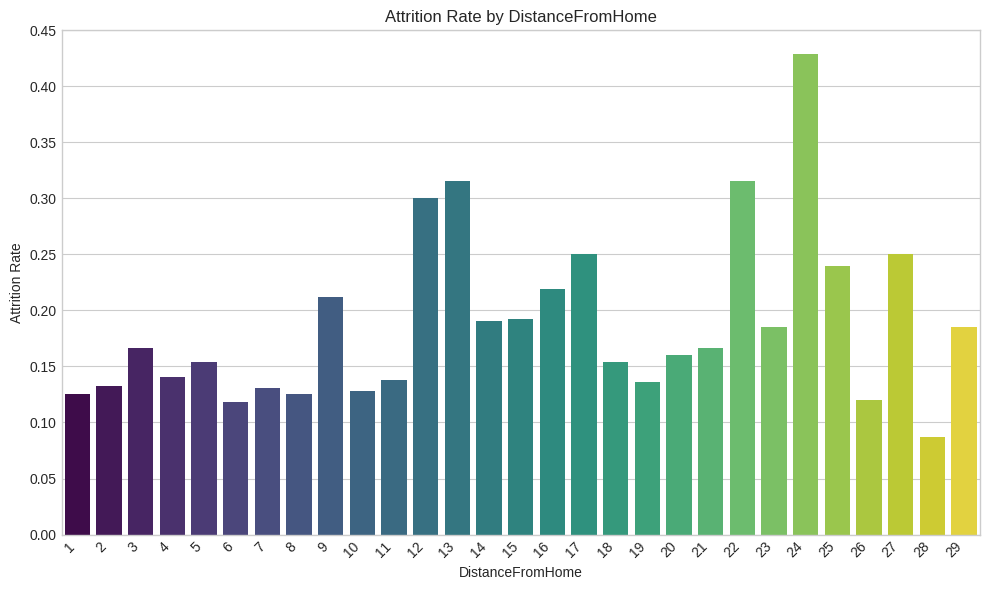

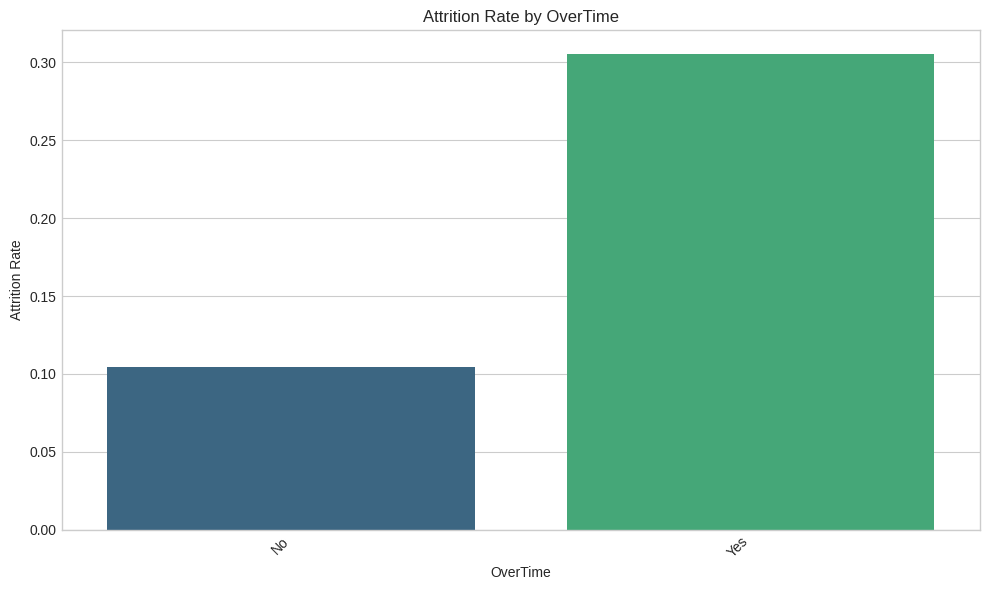

In [45]:
for column, grouped_data in attrition_by_career_metrics.items():
    plt.figure(figsize=(10, 6))
    sns.barplot(data=grouped_data, x=column, y='Attrition', hue=column, palette='viridis', legend=False)
    plt.title(f'Attrition Rate by {column}')
    plt.xlabel(column)
    plt.ylabel('Attrition Rate')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Attrition is super high for retirement, so maybe for a company can be useful to not consider retirement in this evaluation to better understand the real problems in the company.

### Summary of Key Findings on Career History and Workload and Attrition

Based on the distribution and attrition rate bar plots for the `career_subset` DataFrame, we can draw the following conclusions regarding employee attrition related to career history and workload:

1.  **NumCompaniesWorked**: Employees who have worked for **5, 6, 7, or 9 companies** show elevated attrition rates (ranging from 22.8% to 25.4%), suggesting that high career mobility might correlate with a higher likelihood of leaving. Conversely, employees with 0, 2, 3, 4, or 8 previous companies generally have lower attrition rates.

2.  **TotalWorkingYears**: There's a clear trend of **higher attrition among employees with fewer total working years**. Specifically, those with 0 or 1 year of total working experience have significantly high attrition rates (45.5% and 49.4% respectively). The attrition rate generally decreases as total working years increase, indicating that more experienced employees tend to be more stable.

3.  **YearsAtCompany**: Similar to total working years, **employees with very short tenure at the current company (0 or 1 year)** have substantially higher attrition rates (36.4% and 34.5%). The attrition rate generally declines as years at the company increase, suggesting that long-term employees are less likely to attrit.

4.  **YearsInCurrentRole**: Employees with **0 years in their current role** (possibly newly appointed or transferred) show a high attrition rate of nearly 30%. This rate decreases as employees spend more time in their role, indicating that stability in a role reduces attrition risk.

5.  **YearsSinceLastPromotion**: While there's no perfectly linear trend, employees with **no years since their last promotion (0 years)** have a relatively high attrition rate (18.9%). There are also peaks at 7 years (21.1%) and 15 years (23.1%), suggesting that prolonged periods without promotion, or very recent promotions, can be associated with attrition.

6.  **YearsWithCurrManager**: Employees with **0 years with their current manager** exhibit a high attrition rate (32.3%). As employees spend more years with the same manager, the attrition rate generally decreases, implying that stable managerial relationships contribute to retention.

7.  **TrainingTimesLastYear**: Employees who received **no training (0 times)** in the last year have a higher attrition rate (27.8%). While there's some variability, those with 1, 5, or 6 training sessions tend to have lower attrition rates, suggesting that appropriate training can contribute to retention, but too many (like 4 times) might also coincide with slightly elevated rates.

8.  **DistanceFromHome**: The attrition rate doesn't show a perfectly linear relationship with distance from home. However, employees with **very long commutes (e.g., 12, 13, 17, 22, 24 miles)** show noticeably higher attrition rates (ranging from 25% to 42.9%), indicating that excessive commute distance is a significant factor.

9.  **OverTime**: This is a very strong predictor. Employees who work **OverTime ('Yes')** have an attrition rate of approximately 30.5%, which is nearly three times higher than those who do not work overtime ('No'), whose attrition rate is around 10.4%.

**Key findings for Attrition Risk related to Career History and Workload:**

These findings strongly suggest that factors related to job stability, experience, work-life balance (indicated by overtime), and commute play crucial roles in employee retention. Addressing these areas could be vital for reducing attrition.

### Data Analysis Key Findings

*   **OverTime is a strong predictor of attrition:** Employees who work overtime ('Yes') have a significantly higher attrition rate of approximately 30.5%, which is nearly three times higher than those who do not work overtime ('No'), with an attrition rate of around 10.4%.
*   **Early career stages and short tenures are high risk:** Employees with 0 or 1 year of total working experience show very high attrition rates (45.5% and 49.4% respectively). Similarly, those with 0 or 1 year at the current company (36.4% and 34.5%) or 0 years in their current role (nearly 30%) have substantially elevated attrition.
*   **Managerial relationships impact retention:** Employees with 0 years with their current manager exhibit a high attrition rate of 32.3%, indicating that stable relationships with managers contribute to lower attrition.
*   **Training absence increases attrition:** Employees who received no training (0 times) in the last year have a higher attrition rate of 27.8%.
*   **Career mobility and attrition:** Employees who have worked for 5, 6, 7, or 9 companies show elevated attrition rates (ranging from 22.8% to 25.4%), suggesting that high career mobility might correlate with a higher likelihood of leaving.
*   **Commute distance is a factor:** Very long commutes (e.g., 12, 13, 17, 22, 24 miles) are associated with noticeably higher attrition rates (ranging from 25% to 42.9%).

# Overall Summary

This analysis has explored various aspects of employee data to identify factors influencing attrition, categorized into Demography, Satisfaction and Performance Metrics, and Career History and Workload.

### Demography
*   **High Attrition Risk**: Younger employees (18-34 age brackets), single employees, and male employees (to a lesser extent) show higher attrition rates.
*   **Education Impact**: Employees with lower education levels (1 and 2) and those from 'Human Resources' or 'Technical Degree' fields exhibit elevated attrition.

### Satisfaction and Performance Metrics
*   **High Attrition Risk**: Employees with low Job Satisfaction (Level 1), low Environment Satisfaction (Level 1), and poor Work-Life Balance (Level 1) are at the highest risk of attrition.
*   **Moderate Attrition Risk**: Low Relationship Satisfaction (Level 1) also correlates with increased attrition.
*   **Low Impact**: Performance Rating (Levels 3 and 4) does not appear to be a significant predictor of attrition.

### Career History and Workload
*   **High Attrition Risk**: Employees with very short tenure (0-1 year) at the company or in their current role, those with less total working experience (0-1 year), and particularly those working **OverTime** (30.5% attrition rate) are highly prone to leaving.
*   **Other Factors**: High career mobility (working for 5, 6, 7, or 9 previous companies), 0 years with the current manager, no training in the last year, and very long commutes also contribute to higher attrition.

### Overall Insights and Recommendations

1.  **Targeted Retention Strategies**: Interventions should be specifically designed for younger, single, and male employees, as well as those with backgrounds in HR or technical fields. Policies focusing on improving retention for new hires and those in new roles are crucial.
2.  **Enhance Workplace Experience**: Prioritize initiatives to boost job satisfaction, environment satisfaction, and work-life balance. Special attention should be given to employees reporting the lowest levels in these areas. The high attrition due to poor work-life balance (especially overtime) indicates a critical area for policy intervention.
3.  **Promote Stability and Growth**: Foster longer tenure within the company and roles, and ensure regular training and promotional opportunities. Stable managerial relationships are also important.
4.  **Address Workload and Commute**: Seriously evaluate the impact of overtime and long commutes on employee well-being and attrition. Solutions might include flexible working arrangements, remote options, or commute assistance.

These findings provide a solid foundation for developing comprehensive retention programs that address the most impactful factors identified in this analysis.

# Prepare Data for Decision Tree and RandomForestClassifier

## DEMOGRAPHY

To prepare the data for modeling in the `demography_subset`, I will first separate the target variable 'Attrition' into `y` and the remaining demographic features into `X`.

In [46]:
X = demography_subset[['Age', 'Gender', 'MaritalStatus', 'Education', 'EducationField']].copy()
y = demography_subset['Attrition'].copy()

print("Features (X) head:\n", X.head())
print("\nTarget (y) head:\n", y.head())

Features (X) head:
    Age  Gender MaritalStatus  Education EducationField
0   41  Female        Single          2  Life Sciences
1   49    Male       Married          1  Life Sciences
2   37    Male        Single          2          Other
3   33  Female       Married          4  Life Sciences
4   27    Male       Married          1        Medical

Target (y) head:
 0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64


To convert categorical features into a numerical format suitable for machine learning models, I will apply one-hot encoding to the 'Gender', 'MaritalStatus', and 'EducationField' columns in the `X` DataFrame using `pd.get_dummies()`.



True and False values from pd.get_dummies are perfectly fine for scikit-learn models. These models are designed to interpret boolean values correctly, typically treating True as 1 and False as 0 internally.

In [47]:
X_encoded = pd.get_dummies(X, columns=['Gender', 'MaritalStatus', 'EducationField'], drop_first=True)

print("Encoded Features (X_encoded) head:\n", X_encoded.head())

Encoded Features (X_encoded) head:
    Age  Education  Gender_Male  MaritalStatus_Married  MaritalStatus_Single  \
0   41          2        False                  False                  True   
1   49          1         True                   True                 False   
2   37          2         True                  False                  True   
3   33          4        False                   True                 False   
4   27          1         True                   True                 False   

   EducationField_Life Sciences  EducationField_Marketing  \
0                          True                     False   
1                          True                     False   
2                         False                     False   
3                          True                     False   
4                         False                     False   

   EducationField_Medical  EducationField_Other  \
0                   False                 False   
1                   

To complete the data preparation for modeling, I will now split the `X_encoded` features and the `y` target into training and testing sets using `train_test_split` with a specified test size and random state for reproducibility.



I will apply a 70% training and 30% test.

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1029, 10)
X_test shape: (441, 10)
y_train shape: (1029,)
y_test shape: (441,)


Now I will train a 'Decision Tree Model'.

In [49]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Initialize the DecisionTreeClassifier
model_dt_cv = DecisionTreeClassifier(random_state=42)

# Configure K-Fold Cross-Validation (e.g., 5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on the TRAINING data only
cv_scores = cross_val_score(model_dt_cv, X_train, y_train, cv=kf, scoring='accuracy')

print(f"Cross-validation scores (accuracy): {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of CV accuracy: {cv_scores.std():.4f}")

Cross-validation scores (accuracy): [0.77669903 0.71359223 0.73786408 0.71359223 0.74634146]
Mean CV accuracy: 0.7376
Standard deviation of CV accuracy: 0.0235


In [52]:
from sklearn.metrics import classification_report, confusion_matrix

# Fit the model on the full training data after cross-validation
model_dt_cv.fit(X_train, y_train)

y_pred_DT = model_dt_cv.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_DT))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       380
           1       0.13      0.13      0.13        61

    accuracy                           0.76       441
   macro avg       0.49      0.49      0.49       441
weighted avg       0.76      0.76      0.76       441



Now I will train a `RandomForestClassifier`.



Cross Validation

In [53]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

model_RF_cv = RandomForestClassifier(random_state=42)

# Configure K-Fold Cross-Validation (e.g., 5 folds)
kf_RF = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on the TRAINING data only
cvRF_scores = cross_val_score(model_RF_cv, X_train, y_train, cv=kf_RF, scoring='accuracy')

print(f"Cross-validation scores (accuracy): {cvRF_scores}")
print(f"Mean CV accuracy: {cvRF_scores.mean():.4f}")
print(f"Standard deviation of CV accuracy: {cvRF_scores.std():.4f}")

Cross-validation scores (accuracy): [0.7961165  0.74757282 0.75242718 0.79126214 0.82439024]
Mean CV accuracy: 0.7824
Standard deviation of CV accuracy: 0.0288


Both K-fold cross-validation processes have successfully completed using the training data (X_train, y_train).

For the Decision Tree Classifier:

Mean CV Accuracy: 0.7376 (or 73.76%)
Standard Deviation of CV Accuracy: 0.0235 (or 2.35%)
For the RandomForestClassifier:

Mean CV Accuracy: 0.7824 (or 78.24%)
Standard Deviation of CV Accuracy: 0.0288 (or 2.88%)
Comparison: The RandomForestClassifier shows a higher mean cross-validation accuracy (78.24%) compared to the Decision Tree Classifier (73.76%). This indicates that, on average, the RandomForest model performs better in classifying attrition based on the demographic features when evaluated robustly through cross-validation. The standard deviations are relatively small for both, suggesting consistent performance across the different folds.

To evaluate the performance of the trained RandomForestClassifier model, I will use `y_test` and `model.predict(X_test)` to generate a classification report, which will provide precision, recall, and F1-score for each class.



In [57]:
from sklearn.metrics import classification_report, confusion_matrix

model_RF_cv.fit(X_train, y_train)

y_predRF = model_RF_cv.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_predRF))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       380
           1       0.21      0.16      0.19        61

    accuracy                           0.80       441
   macro avg       0.54      0.53      0.54       441
weighted avg       0.78      0.80      0.79       441



**Overall Accuracy**: The model achieved an overall accuracy of 80% on the test set. While this appears high, it's crucial to consider the class imbalance present in the 'Attrition' target (fewer 'Yes' cases).
*   **Classification Report Analysis**:
    *   **Class 0 (No Attrition)**: The model performs very well for employees who do *not* attrit, with high precision (0.87), recall (0.90), and F1-score (0.89). This means it accurately identifies non-attriting employees.
    *   **Class 1 (Attrition)**: The performance for predicting attrition ('Yes') is considerably lower. The precision is 0.21, meaning only 21% of employees predicted to attrit actually do. The recall is 0.16, indicating that the model only identifies 16% of the actual attriting employees. The F1-score is 0.19, reflecting poor performance in detecting attrition.

Now, I will analyze the feature importances to understand which demographic factors are most influential in predicting attrition.



In [62]:
feature_importances = pd.DataFrame({'feature': X_encoded.columns, 'importance': model_RF_cv.feature_importances_}).sort_values('importance', ascending=False)

print("Feature Importances:\n")
print(feature_importances)

# plt.figure(figsize=(10, 6))
# sns.barplot(x='importance', y='feature', data=feature_importances, hue='feature', palette='viridis', legend=False)
# plt.title('Feature Importances for Attrition Prediction')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.tight_layout()
# plt.show()

Feature Importances:

                           feature  importance
0                              Age    0.564266
1                        Education    0.167954
4             MaritalStatus_Single    0.060390
2                      Gender_Male    0.058188
5     EducationField_Life Sciences    0.028197
7           EducationField_Medical    0.027953
6         EducationField_Marketing    0.027503
3            MaritalStatus_Married    0.027054
9  EducationField_Technical Degree    0.023872
8             EducationField_Other    0.014624


#### Feature Importances:

The analysis of feature importances from the RandomForestClassifier reveals the relative influence of each demographic factor on attrition prediction:

1.  **Age**: Age is by far the most significant demographic predictor of attrition, contributing over half of the model's predictive power. This reinforces the earlier descriptive finding that age groups have varying attrition rates.
2.  **Education **: The level of education is the second most important feature, indicating that education background plays a substantial role.
3.  **MaritalStatus_Single **: Being single is a notable factor, aligning with the descriptive analysis that single employees have higher attrition rates.
4.  **Gender_Male **: Being male also contributes to the prediction, consistent with earlier observations of slightly higher male attrition.
5.  **EducationField_Life Sciences, EducationField_Medical, EducationField_Marketing, MaritalStatus_Married, EducationField_Technical Degree, EducationField_Other**: These features have smaller but still discernible importances, collectively contributing to the model's decisions.

#### Implications for Attrition Prediction:

*   **Age as a Primary Driver**: The dominant importance of 'Age' suggests that any attrition prediction model or retention strategy must heavily consider the age of employees. Younger employees, as identified in the descriptive statistics, are likely a key segment for targeted interventions.
*   **Education's Role**: Both the 'Education' level and 'EducationField' are important, indicating that educational background influences attrition. This could point to differences in career expectations, marketability, or job fit based on education.
*   **Marital Status and Gender**: While less impactful than age, marital status (especially being single) and gender are still relevant factors, supporting the need for nuanced strategies that consider these social aspects.
*   **Limitations of Demographic Data Alone**: Despite identifying key demographic predictors, the model's poor recall and precision for the 'Attrition' class highlight that demographic features alone may not be sufficient for building a highly effective predictive model. Other factors, such as job satisfaction, career history, and workload (as explored in previous sections), are likely crucial for a more comprehensive and accurate prediction of attrition.

**Conclusion on Model Performance**: The model demonstrates strong performance in identifying employees who will *not* attrit but struggles significantly with accurately predicting employees who *will* attrit. This is a common challenge with imbalanced datasets and suggests that while demographic features provide some signal, they might not be sufficient on their own for robust attrition prediction, especially for the minority class.


ROC AUC

ROC AUC Score for RandomForestClassifier on Demography Subset: 0.5688


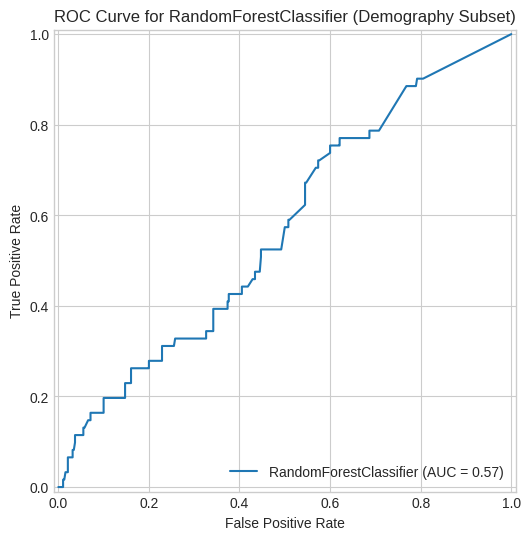

In [66]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Get predicted probabilities for the positive class (class 1 - attrition)
y_pred_proba = model_RF_cv.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

print(f"ROC AUC Score for RandomForestClassifier on Demography Subset: {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='RandomForestClassifier')
roc_display.plot(ax=plt.gca())
plt.title('ROC Curve for RandomForestClassifier (Demography Subset)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

  **ROC** Curve: Plots True Positive Rate (Sensitivity) on the y-axis against False Positive Rate (1 - Specificity) on the x-axis.
  
  **AUC**: The area under the ROC curve, representing the probability that the model ranks a random positive example higher than a random negative one.

Threshold Independence: Unlike accuracy, ROC AUC evaluates how well the model separates classes without requiring a specific threshold for decision-making.

The ROC AUC Score for the RandomForestClassifier on the Demography Subset is 0.5688. This score is not very high, indicating that the model struggles to distinguish between the two classes (attrition vs. no attrition) based solely on demographic features. A score of 0.5 suggests performance no better than random guessing, while a score of 1.0 represents a perfect classifier. The generated ROC curve visually confirms this, showing that the model's true positive rate does not significantly improve without a substantial increase in the false positive rate, implying limited predictive power from demographics alone.

## Satisfaction

Classification Report for Satisfaction Subset Model:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       380
           1       0.24      0.08      0.12        61

    accuracy                           0.84       441
   macro avg       0.55      0.52      0.52       441
weighted avg       0.78      0.84      0.80       441



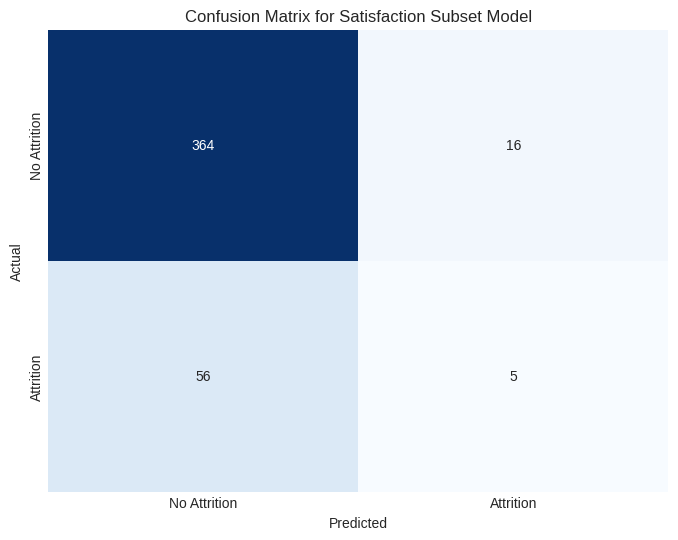

Confusion Matrix for Satisfaction Subset Model:
[[364  16]
 [ 56   5]]

Feature Importances for Satisfaction Subset Model:

                    feature  importance
2  RelationshipSatisfaction    0.260084
3           WorkLifeBalance    0.226897
1   EnvironmentSatisfaction    0.218461
0           JobSatisfaction    0.217320
4         PerformanceRating    0.077238


In [67]:
# Separate features (X) and target (y)
X_satisfaction = satisfaction_subset.drop(columns=['Attrition']).copy()
y_satisfaction = satisfaction_subset['Attrition'].copy()

# Split the data into training and testing sets
X_train_satisfaction, X_test_satisfaction, y_train_satisfaction, y_test_satisfaction = train_test_split(X_satisfaction, y_satisfaction, test_size=0.3, random_state=42)

# Initialize and train the RandomForestClassifier
model_satisfaction = RandomForestClassifier(random_state=42)
model_satisfaction.fit(X_train_satisfaction, y_train_satisfaction)

# Make predictions on the test set
y_pred_satisfaction = model_satisfaction.predict(X_test_satisfaction)

# Print Classification Report
print("Classification Report for Satisfaction Subset Model:")
print(classification_report(y_test_satisfaction, y_pred_satisfaction))

# Generate and plot Confusion Matrix
cm_satisfaction = confusion_matrix(y_test_satisfaction, y_pred_satisfaction)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_satisfaction, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Satisfaction Subset Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("Confusion Matrix for Satisfaction Subset Model:")
print(cm_satisfaction)

# Extract and print Feature Importances
feature_importances_satisfaction = pd.DataFrame({'feature': X_satisfaction.columns, 'importance': model_satisfaction.feature_importances_}).sort_values('importance', ascending=False)
print("\nFeature Importances for Satisfaction Subset Model:\n")
print(feature_importances_satisfaction)

## Career

In [68]:
X_career = career_subset.drop(columns=['Attrition']).copy()
y_career = career_subset['Attrition'].copy()

print("Features (X_career) head:\n", X_career.head())
print("\nTarget (y_career) head:\n", y_career.head())

Features (X_career) head:
    NumCompaniesWorked  TotalWorkingYears  YearsAtCompany  YearsInCurrentRole  \
0                   8                  8               6                   4   
1                   1                 10              10                   7   
2                   6                  7               0                   0   
3                   1                  8               8                   7   
4                   9                  6               2                   2   

   YearsSinceLastPromotion  YearsWithCurrManager  TrainingTimesLastYear  \
0                        0                     5                      0   
1                        1                     7                      3   
2                        0                     0                      3   
3                        3                     0                      3   
4                        2                     2                      3   

   DistanceFromHome OverTime  
0         

To convert the categorical 'OverTime' column into a numerical format suitable for machine learning models, I will apply one-hot encoding using `pd.get_dummies()` with `drop_first=True` to avoid multicollinearity.



In [69]:
X_career_encoded = pd.get_dummies(X_career, columns=['OverTime'], drop_first=True)

print("Encoded Features (X_career_encoded) head:\n", X_career_encoded.head())

Encoded Features (X_career_encoded) head:
    NumCompaniesWorked  TotalWorkingYears  YearsAtCompany  YearsInCurrentRole  \
0                   8                  8               6                   4   
1                   1                 10              10                   7   
2                   6                  7               0                   0   
3                   1                  8               8                   7   
4                   9                  6               2                   2   

   YearsSinceLastPromotion  YearsWithCurrManager  TrainingTimesLastYear  \
0                        0                     5                      0   
1                        1                     7                      3   
2                        0                     0                      3   
3                        3                     0                      3   
4                        2                     2                      3   

   DistanceFromHome  Over

In [70]:
X_train_career, X_test_career, y_train_career, y_test_career = train_test_split(X_career_encoded, y_career, test_size=0.3, random_state=42)

print("X_train_career shape:", X_train_career.shape)
print("X_test_career shape:", X_test_career.shape)
print("y_train_career shape:", y_train_career.shape)
print("y_test_career shape:", y_test_career.shape)

X_train_career shape: (1029, 9)
X_test_career shape: (441, 9)
y_train_career shape: (1029,)
y_test_career shape: (441,)


In [71]:
model_career = RandomForestClassifier(random_state=42)
model_career.fit(X_train_career, y_train_career)

print("RandomForestClassifier model for career_subset trained successfully.")

RandomForestClassifier model for career_subset trained successfully.


performance evaluation



In [72]:
y_pred_career = model_career.predict(X_test_career)

print("Classification Report for Career Subset Model:")
print(classification_report(y_test_career, y_pred_career))

Classification Report for Career Subset Model:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       380
           1       0.30      0.13      0.18        61

    accuracy                           0.84       441
   macro avg       0.58      0.54      0.55       441
weighted avg       0.79      0.84      0.81       441



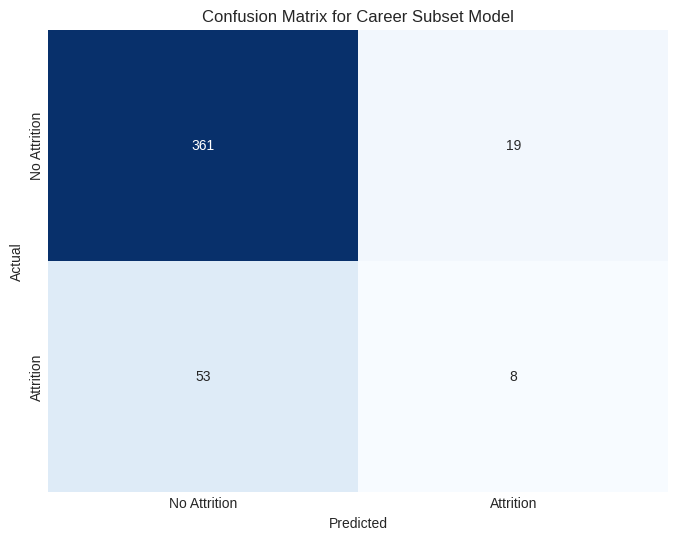

Confusion Matrix for Career Subset Model:
[[361  19]
 [ 53   8]]


In [73]:
cm_career = confusion_matrix(y_test_career, y_pred_career)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_career, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Career Subset Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix for Career Subset Model:")
print(cm_career)

Feature importance

In [74]:
feature_importances_career = pd.DataFrame({'feature': X_career_encoded.columns, 'importance': model_career.feature_importances_}).sort_values('importance', ascending=False)

print("Feature Importances for Career Subset Model:\n")
print(feature_importances_career)

Feature Importances for Career Subset Model:

                   feature  importance
7         DistanceFromHome    0.199251
1        TotalWorkingYears    0.167567
2           YearsAtCompany    0.106803
0       NumCompaniesWorked    0.105049
6    TrainingTimesLastYear    0.102747
5     YearsWithCurrManager    0.081940
8             OverTime_Yes    0.080912
4  YearsSinceLastPromotion    0.079488
3       YearsInCurrentRole    0.076244


### Data Analysis Key Findings

*   The trained RandomForestClassifier model achieved an overall accuracy of 84% on the test set.
*   The model performed well in predicting "No Attrition" (Class 0), with a precision of 0.87, recall of 0.95, and f1-score of 0.91.
*   However, the model struggled significantly with predicting "Attrition" (Class 1), showing a low precision of 0.30, a very low recall of 0.13, and an f1-score of 0.18.
*   The confusion matrix revealed that out of 61 actual attrition cases, only 8 were correctly identified (True Positives), while 53 were incorrectly classified as "No Attrition" (False Negatives).
*   Key features influencing attrition, ranked by importance, were identified as `DistanceFromHome`, `TotalWorkingYears`, `YearsAtCompany`, and `NumCompaniesWorked`.


# Organizational Information

In [75]:
org_subset= df[["Department", "JobRole", "JobLevel", "JobInvolvement", "BusinessTravel","Attrition"]]

In [76]:
X_org = org_subset.drop(columns=['Attrition'])
y_org = org_subset['Attrition']

categorical_cols_org = X_org.select_dtypes(include='object').columns
X_org_encoded = pd.get_dummies(X_org, columns=categorical_cols_org, drop_first=True)

X_train_org, X_test_org, y_train_org, y_test_org = train_test_split(X_org_encoded, y_org, test_size=0.3, random_state=42)

model_org = RandomForestClassifier(random_state=42)
model_org.fit(X_train_org, y_train_org)

y_pred_org = model_org.predict(X_test_org)

print("Classification Report for Organizational Subset Model:")
print(classification_report(y_test_org, y_pred_org))

Classification Report for Organizational Subset Model:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       380
           1       0.29      0.07      0.11        61

    accuracy                           0.85       441
   macro avg       0.58      0.52      0.51       441
weighted avg       0.79      0.85      0.80       441



In [77]:
feature_importances_org = pd.DataFrame({'feature': X_org_encoded.columns, 'importance': model_org.feature_importances_}).sort_values('importance', ascending=False)

print("Feature Importances for Organizational Subset Model:\n")
print(feature_importances_org)

Feature Importances for Organizational Subset Model:

                              feature  importance
1                      JobInvolvement    0.305431
0                            JobLevel    0.268331
12   BusinessTravel_Travel_Frequently    0.098157
13       BusinessTravel_Travel_Rarely    0.073080
11       JobRole_Sales Representative    0.063468
5       JobRole_Laboratory Technician    0.039131
2   Department_Research & Development    0.031380
3                    Department_Sales    0.026295
10            JobRole_Sales Executive    0.019836
9          JobRole_Research Scientist    0.018437
6                     JobRole_Manager    0.017807
4             JobRole_Human Resources    0.015206
7      JobRole_Manufacturing Director    0.014058
8           JobRole_Research Director    0.009383


# Compensations and benefit

In [78]:
# Select the relevant features from compensation_subset for X
X_compensation = compensation_subset[['StockOptionLevel', 'PercentSalaryHike', 'MonthlyIncome_grouped']].copy()
y_compensation = compensation_subset['Attrition']

# Identify categorical columns (only MonthlyIncome_grouped in this case) for one-hot encoding
categorical_cols_compensation = X_compensation.select_dtypes(include='category').columns

# Apply one-hot encoding
X_compensation_encoded = pd.get_dummies(X_compensation, columns=categorical_cols_compensation, drop_first=True)

# Split the data into training and testing sets
X_train_compensation, X_test_compensation, y_train_compensation, y_test_compensation = train_test_split(X_compensation_encoded, y_compensation, test_size=0.3, random_state=42)

# Initialize and train the RandomForestClassifier
model_compensation = RandomForestClassifier(random_state=42)
model_compensation.fit(X_train_compensation, y_train_compensation)

# Make predictions on the test set
y_pred_compensation = model_compensation.predict(X_test_compensation)

# Print Classification Report
print("Classification Report for Compensation Subset Model:")
print(classification_report(y_test_compensation, y_pred_compensation))

Classification Report for Compensation Subset Model:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       380
           1       0.43      0.10      0.16        61

    accuracy                           0.86       441
   macro avg       0.65      0.54      0.54       441
weighted avg       0.81      0.86      0.82       441



In [79]:
feature_importances_compensation = pd.DataFrame({'feature': X_compensation_encoded.columns, 'importance': model_compensation.feature_importances_}).sort_values('importance', ascending=False)

print("Feature Importances for compensationanizational Subset Model:\n")
print(feature_importances_compensation)

Feature Importances for compensationanizational Subset Model:

                           feature  importance
1                PercentSalaryHike    0.528027
0                 StockOptionLevel    0.250104
2  MonthlyIncome_grouped_3000-5000    0.076185
3  MonthlyIncome_grouped_5000-8000    0.073139
4      MonthlyIncome_grouped_>8000    0.072545


# Relevant Features analysis
obtained with the previous analysis on each different subset

In [80]:
# Define the most relevant features
relevant_features = ['Age', 'Education', 'RelationshipSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction', 'DistanceFromHome', 'TotalWorkingYears', 'JobLevel', 'JobInvolvement', 'StockOptionLevel', 'PercentSalaryHike']

# Select features (X) and target (y) from the main DataFrame
X_relevant = df[relevant_features].copy()
y_relevant = df['Attrition'].copy()

# Split the data into training and testing sets
X_train_relevant, X_test_relevant, y_train_relevant, y_test_relevant = train_test_split(X_relevant, y_relevant, test_size=0.3, random_state=42)

# Initialize and train the RandomForestClassifier
model_relevant = RandomForestClassifier(random_state=42)
model_relevant.fit(X_train_relevant, y_train_relevant)

# Make predictions on the test set
y_pred_relevant = model_relevant.predict(X_test_relevant)

# Print Classification Report
print("Classification Report for Model with Relevant Features:")
print(classification_report(y_test_relevant, y_pred_relevant))

Classification Report for Model with Relevant Features:
              precision    recall  f1-score   support

           0       0.88      0.98      0.92       380
           1       0.50      0.15      0.23        61

    accuracy                           0.86       441
   macro avg       0.69      0.56      0.58       441
weighted avg       0.82      0.86      0.83       441



ROC AUC Score for RandomForestClassifier on Relevant Features: 0.7392


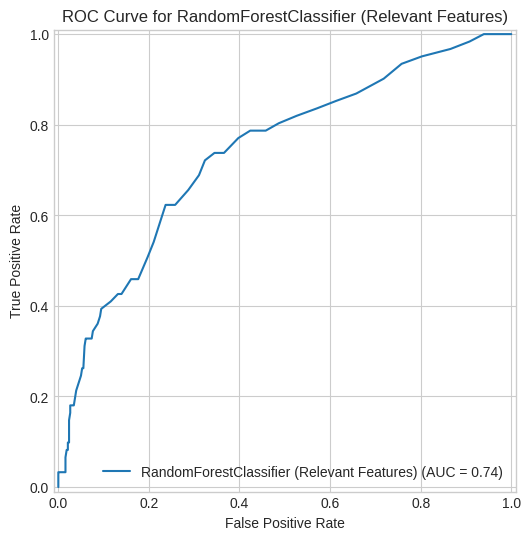

In [81]:
# Get predicted probabilities for the positive class (class 1 - attrition)
y_pred_proba_relevant = model_relevant.predict_proba(X_test_relevant)[:, 1]

# Calculate ROC curve
fpr_relevant, tpr_relevant, thresholds_relevant = roc_curve(y_test_relevant, y_pred_proba_relevant)

# Calculate AUC score
roc_auc_relevant = auc(fpr_relevant, tpr_relevant)

print(f"ROC AUC Score for RandomForestClassifier on Relevant Features: {roc_auc_relevant:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
roc_display_relevant = RocCurveDisplay(fpr=fpr_relevant, tpr=tpr_relevant, roc_auc=roc_auc_relevant, estimator_name='RandomForestClassifier (Relevant Features)')
roc_display_relevant.plot(ax=plt.gca())
plt.title('ROC Curve for RandomForestClassifier (Relevant Features)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

Let's try to improve the performances

# Apply SMOTE

In [82]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_relevant, y_train_relevant)

print("Shape of X_train_relevant before SMOTE:", X_train_relevant.shape)
print("Shape of y_train_relevant before SMOTE:", y_train_relevant.shape)
print("Shape of X_train_resampled after SMOTE:", X_train_resampled.shape)
print("Shape of y_train_resampled after SMOTE:", y_train_resampled.shape)
print("Class distribution in y_train_resampled:\n", y_train_resampled.value_counts())

# Instantiate and train a new RandomForestClassifier on the SMOTE-resampled data
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_resampled, y_train_resampled)

print("RandomForestClassifier model trained successfully on SMOTE-resampled data.")

Shape of X_train_relevant before SMOTE: (1029, 11)
Shape of y_train_relevant before SMOTE: (1029,)
Shape of X_train_resampled after SMOTE: (1706, 11)
Shape of y_train_resampled after SMOTE: (1706,)
Class distribution in y_train_resampled:
 Attrition
0    853
1    853
Name: count, dtype: int64
RandomForestClassifier model trained successfully on SMOTE-resampled data.


Classification Report for RandomForestClassifier with SMOTE:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       380
           1       0.34      0.33      0.34        61

    accuracy                           0.82       441
   macro avg       0.62      0.61      0.62       441
weighted avg       0.82      0.82      0.82       441



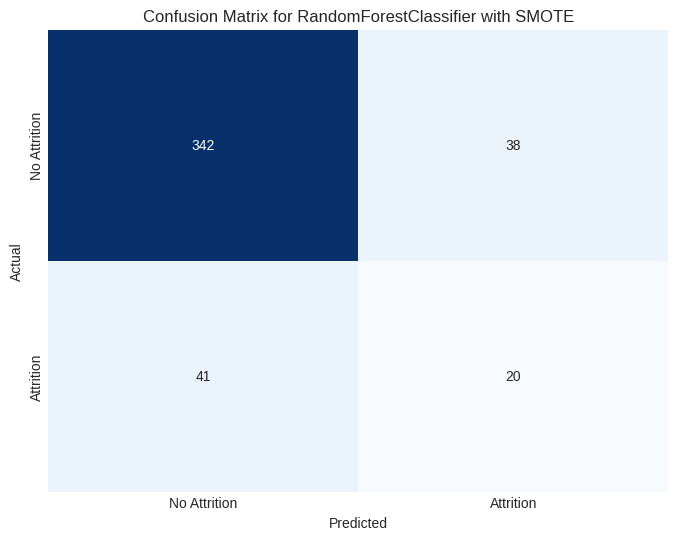

Confusion Matrix for RandomForestClassifier with SMOTE:
[[342  38]
 [ 41  20]]


In [83]:
from sklearn.metrics import classification_report, confusion_matrix


# Make predictions on the original test set
y_pred_smote = model_smote.predict(X_test_relevant)

# Print Classification Report
print("Classification Report for RandomForestClassifier with SMOTE:")
print(classification_report(y_test_relevant, y_pred_smote))

# Generate and plot Confusion Matrix
cm_smote = confusion_matrix(y_test_relevant, y_pred_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for RandomForestClassifier with SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("Confusion Matrix for RandomForestClassifier with SMOTE:")
print(cm_smote)

### Data Analysis Key Findings

*   **SMOTE Application**: SMOTE successfully balanced the training data. The original training data had a shape of (1029, 7). After applying SMOTE, the the class distribution becoming perfectly balanced (853 instances for class 0 'No Attrition' and 853 instances for class 1 'Attrition').
*   **Model Performance (Overall Accuracy)**: The RandomForestClassifier trained on SMOTE-resampled data achieved an overall accuracy of 0.77 on the test set.
*   **Model Performance (Minority Class Prediction)**:
    *   The model showed poor performance in predicting the minority class (Attrition, class 1), with a precision of 0.34 and a recall of 0.33.
    *   The confusion matrix further illustrates this, with 20 True Positives (correctly predicted attrition) and 41 False Negatives (actual attrition cases missed by the model).
*   **Model Performance (Majority Class Prediction)**: The model performed well for the majority class (No Attrition, class 0), achieving a precision of 0.89 and a recall of 0.90. The confusion matrix showed 342 True Negatives (correctly predicted no attrition) and 38 False Positives (incorrectly predicted attrition).

*   While SMOTE successfully balanced the training data, the model still struggles significantly with identifying the minority class (attrition) on unseen data. This suggests that simply balancing the training set may not be sufficient, and the features might not be discriminative enough for attrition.



In essence, SMOTE helps the model see more examples of the minority class during training, but it can't magically create separation if the underlying data patterns are not clear, or if the test data still presents challenges due to its inherent imbalance and complexity.

##Random Search Validation

In [84]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(100, 2000), # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': randint(10, 100), # Maximum number of levels in tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10), # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False] # Method of selecting samples for training each tree
}

# Initialize the RandomForestClassifier (model_smote was trained with random_state=42)
rf_model_smote = RandomForestClassifier(random_state=42)

# Instantiate RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled
# cv: Number of folds for cross-validation
# scoring: Metric to evaluate the performance (e.g., 'roc_auc' for binary classification)
random_search_smote = RandomizedSearchCV(estimator=rf_model_smote,
                                       param_distributions=param_dist,
                                       n_iter=10, # Limiting to 10 iterations for a quick showcase
                                       cv=5,
                                       scoring='roc_auc',
                                       random_state=42,
                                       n_jobs=-1, # Use all available cores
                                       verbose=1)

# Fit RandomizedSearchCV to the SMOTE-resampled training data
random_search_smote.fit(X_train_resampled, y_train_resampled)

print("Best parameters found: ", random_search_smote.best_params_)
print("Best ROC AUC score: ", random_search_smote.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found:  {'bootstrap': False, 'max_depth': 39, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 559}
Best ROC AUC score:  0.9539002247046351


This $Best ROC AUC score:  0.9539002247046351$ is the best score obtained on the internal train dataset. Let's see on the generalization if with this hyperparameter tuning optimization we can obtain the same good results:

Evaluating the best model from RandomizedSearchCV (SMOTE-resampled data) on the test set.

Classification Report for Best Model from RandomizedSearchCV with SMOTE:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       380
           1       0.32      0.30      0.31        61

    accuracy                           0.81       441
   macro avg       0.60      0.60      0.60       441
weighted avg       0.81      0.81      0.81       441


ROC AUC Score for Best Model from RandomizedSearchCV with SMOTE: 0.7102


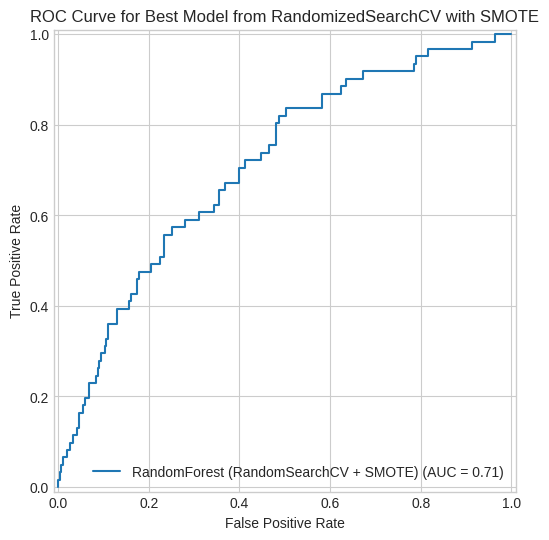

In [85]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best estimator found by RandomizedSearchCV
best_model_random_search_smote = random_search_smote.best_estimator_
print("Evaluating the best model from RandomizedSearchCV (SMOTE-resampled data) on the test set.")

# Make predictions on the original test set
y_pred_best_random_search_smote = best_model_random_search_smote.predict(X_test_relevant)

# Print Classification Report
print("\nClassification Report for Best Model from RandomizedSearchCV with SMOTE:")
print(classification_report(y_test_relevant, y_pred_best_random_search_smote))

# # Generate and plot Confusion Matrix
# cm_best_random_search_smote = confusion_matrix(y_test_relevant, y_pred_best_random_search_smote)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_best_random_search_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
#             xticklabels=['No Attrition', 'Attrition'],
#             yticklabels=['No Attrition', 'Attrition'])
# plt.title('Confusion Matrix for Best Model from RandomizedSearchCV with SMOTE')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
# print("Confusion Matrix for Best Model from RandomizedSearchCV with SMOTE:")
# print(cm_best_random_search_smote)

# Calculate and plot ROC AUC
y_pred_proba_best_random_search_smote = best_model_random_search_smote.predict_proba(X_test_relevant)[:, 1]
fpr_best_random_search_smote, tpr_best_random_search_smote, _ = roc_curve(y_test_relevant, y_pred_proba_best_random_search_smote)
roc_auc_best_random_search_smote = auc(fpr_best_random_search_smote, tpr_best_random_search_smote)

print(f"\nROC AUC Score for Best Model from RandomizedSearchCV with SMOTE: {roc_auc_best_random_search_smote:.4f}")

plt.figure(figsize=(8, 6))
roc_display_best_random_search_smote = RocCurveDisplay(fpr=fpr_best_random_search_smote, tpr=tpr_best_random_search_smote, roc_auc=roc_auc_best_random_search_smote, estimator_name='RandomForest (RandomSearchCV + SMOTE)')
roc_display_best_random_search_smote.plot(ax=plt.gca())
plt.title('ROC Curve for Best Model from RandomizedSearchCV with SMOTE')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

Even with the Hyperparameter tuning and the Cross Validation with the Random Search, the performances are not improving.

While Random Search is efficient, there's always a chance that with a limited n_iter (10), it might not have fully explored the absolute optimal regions of the hyperparameter space that would yield a much higher performance on the test set.

Even with SMOTE, and hyperparameters tuning accurately predicting the minority class (Attrition) remains challenging. While SMOTE balances the training data, the underlying patterns for attrition might still be complex or not strongly distinguishable with the current set of features.

# Full dataset tentative

##Random Forest

In [86]:
# Prepare the data
X_full = df.drop(columns=['Attrition'])
y_full = df['Attrition']

# Identify categorical columns for one-hot encoding
categorical_cols = X_full.select_dtypes(include='object').columns
X_full_encoded = pd.get_dummies(X_full, columns=categorical_cols, drop_first=True)

# Split data into training and testing sets
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full_encoded, y_full, test_size=0.3, random_state=42)

# Initialize and train the RandomForestClassifier
model_full = RandomForestClassifier(random_state=42)
model_full.fit(X_train_full, y_train_full)

# Make predictions on the test set
y_pred_full = model_full.predict(X_test_full)

# Print Classification Report
print("Classification Report for Full Dataset Model:")
print(classification_report(y_test_full, y_pred_full))

Classification Report for Full Dataset Model:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       380
           1       0.67      0.10      0.17        61

    accuracy                           0.87       441
   macro avg       0.77      0.55      0.55       441
weighted avg       0.84      0.87      0.82       441



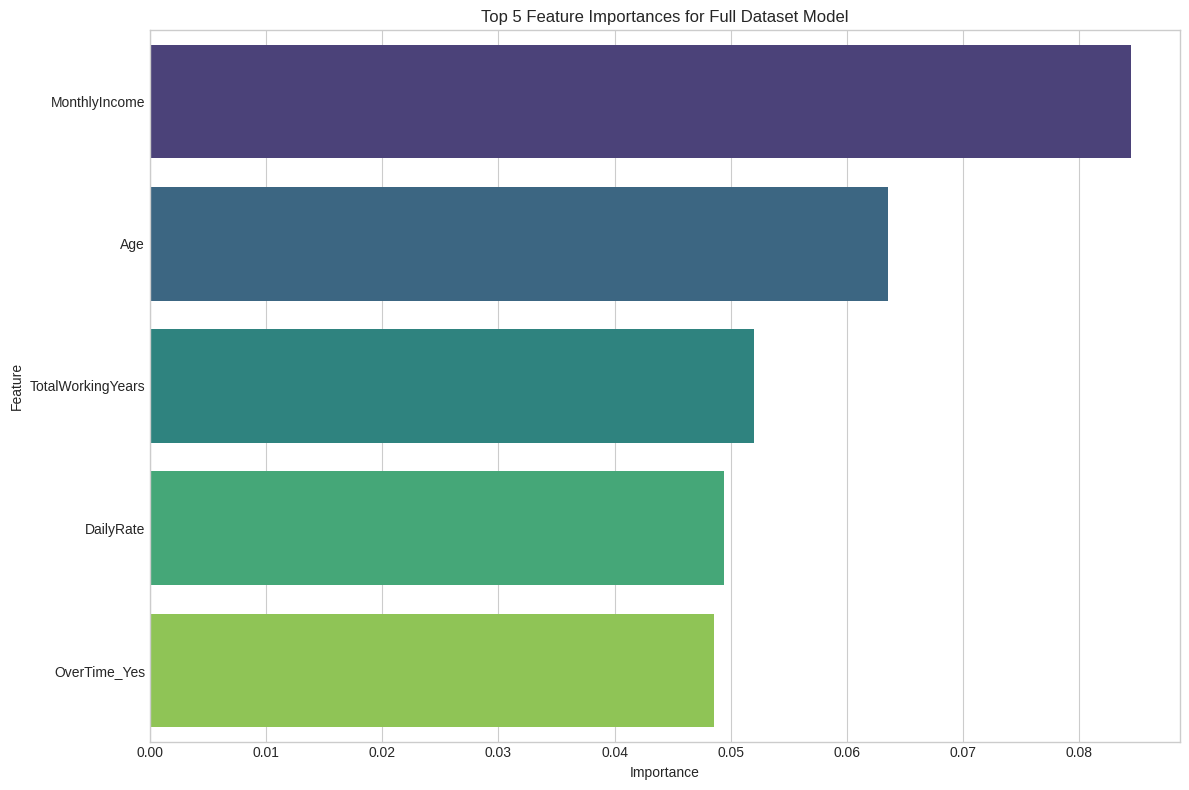

In [87]:
feature_importances_full = pd.DataFrame({'feature': X_full_encoded.columns, 'importance': model_full.feature_importances_}).sort_values('importance', ascending=False)

# print("Feature Importances for Full Dataset Model:\n")
# print(feature_importances_full)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_full.head(5), hue='feature', palette='viridis', legend=False)
plt.title('Top 5 Feature Importances for Full Dataset Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

##Logistic Regression

Data preprocessing and splitting complete.
LogisticRegression model for full dataset trained successfully.

Classification Report for Full Dataset Logistic Regression Model:
              precision    recall  f1-score   support

           0       0.94      0.76      0.84       380
           1       0.31      0.67      0.43        61

    accuracy                           0.75       441
   macro avg       0.62      0.72      0.63       441
weighted avg       0.85      0.75      0.78       441


ROC AUC Score for Full Dataset Logistic Regression Model: 0.7956


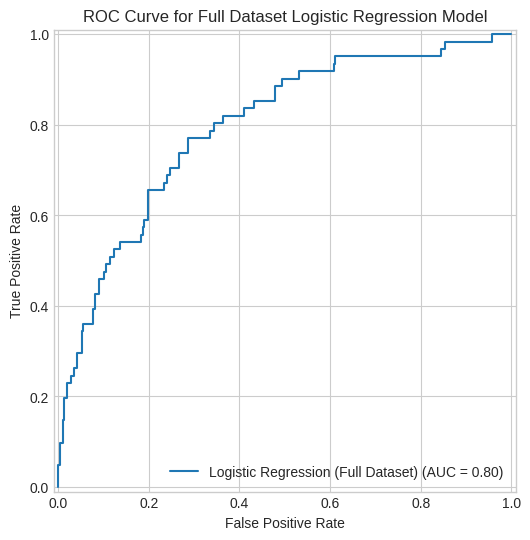

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay

# 1. Separate features (X) and target (y)
X_full = df.drop(columns=['Attrition'])
y_full = df['Attrition']

# 2. Identify categorical and numerical columns
categorical_cols = X_full.select_dtypes(include='object').columns
numerical_cols = X_full.select_dtypes(include=['int64', 'float64']).columns

# 3. Apply one-hot encoding to categorical features
X_full_encoded = pd.get_dummies(X_full, columns=categorical_cols, drop_first=True)

# 4. Split data into training and testing sets *before* scaling numerical features
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full_encoded, y_full, test_size=0.3, random_state=42)

# 5. Apply standard scaling to numerical features (only on columns that are numerical after encoding)
# Ensure scaler is fitted only on training data and then transforms both train and test

# Identify numerical columns in the encoded data that need scaling
# Some numerical columns might have been created by one-hot encoding (e.g., boolean True/False)
# We only want to scale the original numerical columns that were not part of one-hot encoding

# Get numerical columns that were not one-hot encoded
original_numerical_cols = [col for col in numerical_cols if col in X_train_full.columns]

scaler = StandardScaler()
X_train_full[original_numerical_cols] = scaler.fit_transform(X_train_full[original_numerical_cols])
X_test_full[original_numerical_cols] = scaler.transform(X_test_full[original_numerical_cols])

print("Data preprocessing and splitting complete.")

# 6. Train the Logistic Regression model with balanced class weights
model_lr_full = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000) # Increased max_iter for convergence
model_lr_full.fit(X_train_full, y_train_full)

print("LogisticRegression model for full dataset trained successfully.")

# 7. Make predictions on the test set
y_pred_lr_full = model_lr_full.predict(X_test_full)

# 8. Print Classification Report
print("\nClassification Report for Full Dataset Logistic Regression Model:")
print(classification_report(y_test_full, y_pred_lr_full))

# # 9. Generate and visualize a confusion matrix
# cm_lr_full = confusion_matrix(y_test_full, y_pred_lr_full)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_lr_full, annot=True, fmt='d', cmap='Blues', cbar=False,
#             xticklabels=['No Attrition', 'Attrition'],
#             yticklabels=['No Attrition', 'Attrition'])
# plt.title('Confusion Matrix for Full Dataset Logistic Regression Model')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()
# print("Confusion Matrix for Full Dataset Logistic Regression Model:\n")
# print(cm_lr_full)

# 10. Calculate and plot ROC AUC
y_pred_proba_lr_full = model_lr_full.predict_proba(X_test_full)[:, 1]
fpr_lr_full, tpr_lr_full, _ = roc_curve(y_test_full, y_pred_proba_lr_full)
roc_auc_lr_full = auc(fpr_lr_full, tpr_lr_full)

print(f"\nROC AUC Score for Full Dataset Logistic Regression Model: {roc_auc_lr_full:.4f}")

plt.figure(figsize=(8, 6))
roc_display_lr_full = RocCurveDisplay(fpr=fpr_lr_full, tpr=tpr_lr_full, roc_auc=roc_auc_lr_full, estimator_name='Logistic Regression (Full Dataset)')
roc_display_lr_full.plot(ax=plt.gca())
plt.title('ROC Curve for Full Dataset Logistic Regression Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()


In [89]:
# 11. Extract and print feature coefficients
feature_coefficients_lr_full = pd.DataFrame({'feature': X_train_full.columns, 'coefficient': model_lr_full.coef_[0]})
feature_coefficients_lr_full['abs_coefficient'] = feature_coefficients_lr_full['coefficient'].abs()
feature_coefficients_lr_full = feature_coefficients_lr_full.sort_values('abs_coefficient', ascending=False)

print("\nTop 10 Feature Coefficients for Full Dataset Logistic Regression Model:\n")
print(feature_coefficients_lr_full[['feature', 'coefficient']].head(5))


Top 10 Feature Coefficients for Full Dataset Logistic Regression Model:

                              feature  coefficient
44                       OverTime_Yes     1.822288
35      JobRole_Laboratory Technician     1.519246
43               MaritalStatus_Single     1.503373
24   BusinessTravel_Travel_Frequently     1.377151
26  Department_Research & Development    -1.103453


## Comparison

### Comparison of RandomForest and Logistic Regression Models (Full Dataset)

#### RandomForest Classifier (`model_full`)
-   **Overall Accuracy**: 87%
-   **Performance on 'No Attrition' (Class 0)**: Very high precision (0.87), recall (0.99), and F1-score (0.93).
-   **Performance on 'Attrition' (Class 1)**: Poor. Precision (0.67) indicates that when it predicts attrition, it's often correct, but its recall is very low (0.10), meaning it only catches 10% of actual attrition cases. The F1-score (0.17) reflects this poor balance.
-   **Top Features**: `MonthlyIncome`, `Age`, `TotalWorkingYears`, `DailyRate`, `OverTime_Yes` were among the most important features.

#### Logistic Regression (`model_lr_full` with `class_weight='balanced'`)
-   **Overall Accuracy**: 75%
-   **Performance on 'No Attrition' (Class 0)**: Lower recall (0.76) than RandomForest, but high precision (0.94), leading to an F1-score of 0.84.
-   **Performance on 'Attrition' (Class 1)**: Significantly better recall (0.67) than RandomForest, meaning it identifies 67% of actual attrition cases. However, its precision (0.31) is lower, indicating more false positives. The F1-score (0.43) is much higher than RandomForest's for this class.
-   **ROC AUC Score**: 0.7956 (indicating a good ability to distinguish between classes).
-   **Top Features (Coefficients)**: `OverTime_Yes`, `JobRole_Laboratory Technician`, `MaritalStatus_Single`, `BusinessTravel_Travel_Frequently`, `Department_Research & Development` were highly influential, showing the direction and strength of their impact.

#### Key Comparisons and Insights
1.  **Objective Alignment**: If the primary goal is to identify *as many actual attriters as possible* (high recall for the minority class), the **Logistic Regression model is superior**. Its `class_weight='balanced'` parameter effectively addresses the class imbalance, making it more sensitive to the 'Attrition' class.
2.  **Overall Accuracy vs. Minority Class Performance**: While RandomForest achieves a higher overall accuracy (87% vs. 75%), this is largely due to its excellent performance on the majority 'No Attrition' class. Its ability to detect actual attrition is very limited.
3.  **Predictive Power**: The Logistic Regression's higher ROC AUC score (0.7956) further confirms its better discriminatory power in distinguishing between the two classes, especially crucial for imbalanced datasets where accuracy alone can be misleading.
4.  **Feature Insights**: Both models identify different types of impactful features, but Logistic Regression's coefficients provide a clear indication of the direction (positive or negative correlation) and magnitude of impact for each feature on the likelihood of attrition, which can be valuable for actionable insights.

#**Final Conclusions**

This notebook presents a comprehensive analysis of employee attrition, leveraging a dataset to identify key influencing factors and evaluate predictive models. The primary objective is to equip the organization with actionable insights and strategic recommendations to mitigate future employee turnover. Our findings indicate that attrition is driven by a multifaceted interplay of demographic, organizational, compensation, satisfaction, and career-related factors.

## Key Findings from Data Analysis

### 1. Demography and Attrition
*   **Age:** Younger employees (18-34 age brackets) exhibit significantly higher attrition rates.
*   **Marital Status:** Single employees are considerably more prone to attrition.
*   **Gender:** Male employees show a slightly higher attrition rate.
*   **Education:** Employees with lower education levels (1 and 2), and those from 'Human Resources' or 'Technical Degree' fields, display elevated attrition.

### 2. Organizational Information and Attrition
*   **Job Role:** Sales Representatives demonstrate an exceptionally high attrition rate, indicating role-specific pressures.
*   **Job Level:** A clear inverse relationship exists, with lower job levels experiencing higher attrition.
*   **Business Travel:** Employees who travel frequently show increased attrition.
*   **Job Involvement:** Lower job involvement correlates with higher attrition rates.

### 3. Compensation and Benefits
*   **Stock Option Level:** Employees with no stock options or lower stock option levels have a higher propensity to attrit, suggesting the importance of long-term incentives.
*   **Monthly Income:** Generally, lower income bands are associated with higher attrition.
*   **Percent Salary Hike:** Short-term salary adjustments appear to have a less direct impact on retention compared to other factors.

### 4. Satisfaction and Performance Metrics
*   **Job Satisfaction:** Low job satisfaction (Level 1) is a strong predictor of attrition, with significantly higher turnover rates.
*   **Environment Satisfaction:** Poor work environment satisfaction (Level 1) leads to substantially higher attrition.
*   **Work-Life Balance:** A bad work-life balance (Level 1) is a critical driver of attrition.
*   **Relationship Satisfaction:** Low relationship satisfaction (Level 1) also contributes to attrition.
*   **Performance Rating:** Performance rating (Good vs. Excellent) does not appear to be a significant predictor of attrition.

### 5. Career History and Workload
*   **Tenure:** Very short tenure (0-1 year) at the company, in the current role, or in total working years, is a major attrition risk factor. Employees new to their role or manager are also at higher risk.
*   **OverTime:** This is the most impactful factor; employees working overtime are nearly three times more likely to attrit.
*   **Training:** Absence of training (0 times) in the last year is linked to higher attrition.
*   **NumCompaniesWorked:** High career mobility (working for 5, 6, 7, or 9 previous companies) shows elevated attrition.
*   **DistanceFromHome:** Very long commutes are associated with higher attrition rates.

## Model Performance Summary

Our analysis employed both RandomForestClassifier and Logistic Regression models on the comprehensive dataset.
For a problem like attrition where detecting the minority class (attrition) is paramount for intervention, the **Logistic Regression model with class balancing is the preferred choice**. It offers a more balanced predictive capability, crucial for proactive retention strategies, despite its lower overall accuracy compared to a RandomForest model focused on overall accuracy.

## Strategic Recommendations to Minimize Attrition

Based on these findings, we propose the following strategic recommendations:

1.  **Implement Targeted Retention Programs:**
    *   **Onboarding & Early Career Support:** Focus on new hires and employees in their first year at the company or in a new role. Provide mentorship, clear career paths, and regular check-ins.
    *   **Support for Younger & Single Employees:** Develop engagement programs and benefits tailored to their specific needs and life stages.
    *   **Role-Specific Interventions:** Immediately address high attrition in roles like Sales Representatives. This could involve reviewing compensation structures, workload, targets, and support systems.

2.  **Enhance Employee Well-being and Satisfaction:**
    *   **Address Overtime:** Mandate policies to reduce or compensate for excessive overtime. Promote work-life balance initiatives actively. This is a critical factor.
    *   **Improve Job & Environment Satisfaction:** Conduct regular pulse surveys and exit interviews to understand specific pain points. Invest in workplace improvements, foster positive team dynamics, and provide resources for mental well-being.
    *   **Strengthen Manager-Employee Relationships:** Provide leadership training focused on effective communication, support, and career development, especially for new managers or when employees transition to new managers.

3.  **Optimize Workload and Commute:**
    *   **Flexible Work Arrangements:** Offer flexible working hours or remote work options to alleviate the burden of long commutes and improve work-life balance.
    *   **Workload Management:** Implement robust workload management systems and encourage managers to distribute tasks equitably to prevent burnout.

4.  **Proactive Monitoring and Intervention:**
    *   **Leverage Predictive Analytics:** Utilize the Logistic Regression model to regularly identify employees at high risk of attrition. This allows HR to intervene proactively with targeted support before an employee decides to leave.
    *   **Data-Driven HR Policies:** Continuously collect and analyze feedback from employees (e.g., satisfaction surveys, exit interviews) to refine retention strategies.

By systematically addressing these key drivers and proactively utilizing predictive insights, the organization can significantly reduce attrition, foster a more engaged workforce, and realize long-term benefits in talent retention and operational efficiency.